In [1]:
import os
print(os.environ['CONDA_DEFAULT_ENV'])

import sys
print("User Current Version:-", sys.version)

sctl
User Current Version:- 3.10.17 | packaged by conda-forge | (main, Apr 10 2025, 22:19:12) [GCC 13.3.0]


In [2]:
'''


This notebook preprosses single cell data from cell ranger output to clutering .

THe same pbmc3k data used in the seurat tutorial is used as an example  

It largely follows the scanpy tutorial 
https://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html


'''

'\n\n\nThis notebook preprosses single cell data from cell ranger output to clutering .\n\nTHe same pbmc3k data used in the seurat tutorial is used as an example  \n\nIt largely follows the scanpy tutorial \nhttps://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html\n\n\n'

With the exceptions of *IL7R*, which is only found by the t-test and *FCER1A*, which is only found by the other two appraoches, all marker genes are recovered in all approaches.

Louvain Group | Markers | Cell Type
---|---|---
0 | IL7R | CD4 T cells
1 | CD14, LYZ | CD14+ Monocytes
2 | MS4A1 |	B cells
3 | CD8A |	CD8 T cells
4 | GNLY, NKG7 | 	NK cells
5 | FCGR3A, MS4A7 |	FCGR3A+ Monocytes
6 | FCER1A, CST3 |	Dendritic Cells
7 | PPBP |	Megakaryocytes

# Download data and load modules / paths 

In [3]:
#!mkdir data
#!wget http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz -O data/pbmc3k_filtered_gene_bc_matrices.tar.gz
#!cd data; tar -xzf pbmc3k_filtered_gene_bc_matrices.tar.gz
#!mkdir write


In [4]:
# suppress future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
repo_parent_dir='../../../'

import sys
if repo_parent_dir not in sys.path:
    sys.path.append(repo_parent_dir)

# import single_cell_python_tools as sctl
import single_cell_python_tools as sctl
# import the DATASET_class class module
from single_cell_python_tools.DATASET_class import *
# print the docstring of the class
print(sctl.DATASET_class.__doc__)
print(DATASET_class.__doc__)


End‑to‑end single‑cell workflow with a central *parameters* dictionary.
End‑to‑end single‑cell workflow with a central *parameters* dictionary.


In [6]:
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples

# use adata and scanpy tools package functions scanpy wrappers

### first lets try some doc strings 

In [7]:
print(sctl.pp.basic_filitering.__doc__)

 Basic Filtering
    #### code 
    def basic_filitering(adata,
                     filter_cells_min_counts=0,
                      filter_cells_min_genes=200,
                     filter_genes_min_cells=3,
                     filter_genes_min_counts=0,
                     **parameters
                     ):
    logger.info(f" {adata.n_obs} observations BEFORE Basic Filtering (min_genes and min_counts)")
    #print(f" {adata.n_obs} observations BEFORE Basic Filtering")
    sc.pp.filter_cells(adata, min_genes=filter_cells_min_genes)  #min_genes=over_n_genes_bycounts
    logger.info(f" Filtering cells  sc.pp.filter_cells(adata, min_genes={filter_cells_min_genes})")
    logger.info(f' {adata.n_obs} observations AFTER  min_genes Filtering, min_genes={filter_cells_min_genes}')
    sc.pp.filter_cells(adata,min_counts=filter_cells_min_counts)  # blob:vscode-webview://0u0ee01ocem66lh0f6iv38q91fv5oefgtqfcfp0erindjr0nlt15/38da57ab-a0fb-4ac4-b82c-7af52ba03531cells / observations must have mi

In [8]:
print(sctl.pp.annotate_n_view_adata_raw_counts.__doc__)

  
    Annotate technical gene groups  and calculate qc metrics
    #### code 
    annotate_QC_genes(adata)
    calculate_qc_metrics(adata)
    plot_qc_metrics(adata)
    


In [9]:
print(sctl.pp.annotate_QC_genes.__doc__)
print(sctl.pp.calculate_qc_metrics.__doc__)
print(sctl.pp.plot_qc_metrics.__doc__)

 
    logger.info(f"
Organism is set to {organism}")
    if organism == 'human' or None:
        logger.info(f"annotating human genes")
        #print ('Organism is human, annotating human genes')
        adata.var['mt'] = adata.var_names.str.startswith("MT-")  # mitochondrial genes as 'mt'
        adata.var['ribo'] = adata.var_names.str.startswith(("RPS","RPL")) # ribosomal genes genes as 'ribo'
        adata.var['hb'] = adata.var_names.str.contains(("^HB[^(P)(S)]")) & ~adata.var_names.str.contains(("HBEGF")) 
        # "^HB[^(P)" changed to "^HB[^(P)(S)" and  & ~adata_test.var_names.str.contains(("HBEGF")) added to remove HBS1L and HBEGF which are NOT memoglobin genes
        adata.var['malat1'] = adata.var_names.str.contains(("MALAT1"))  # MALAT1 genes as 'malat1'
    if organism == 'mouse':
        logger.info(f" annotating mouse QC genes")
        #print ('Organism is mouse, annotating mouse genes')
        adata.var['mt'] = adata.var_names.str.startswith("mt-")  # mitochondrial g

In [10]:
print(sctl.pp.annotate_n_view_adata_raw_counts.__doc__)

  
    Annotate technical gene groups  and calculate qc metrics
    #### code 
    annotate_QC_genes(adata)
    calculate_qc_metrics(adata)
    plot_qc_metrics(adata)
    


In [11]:
print(sctl.pp.remove_genes.__doc__)

 ################################# Remove Filter out genes with ""techincal bias""
    
    
    #### code
    
    def remove_genes(adata,
                remove_MALAT1=False,
                remove_MT=False,
                remove_HB=False,
                remove_RP_SL=False,
                remove_MRP_SL=False,
                 **parameters
                ):
    ### Remove gene sets  on off switches
    logger.info(f'
 ####################################################  remove_genes')
    logger.info(f'remove_MALAT1 : {remove_MALAT1}')
    logger.info(f'remove_MT : {remove_MT}')
    logger.info(f'remove_HB : {remove_HB}')
    logger.info(f'remove_RP_SL : {remove_RP_SL}')
    logger.info(f'remove_MRP_SL : {remove_MRP_SL} ')
    logger.info(f" {adata.n_vars} features BEFORE Filtering for specific genes and {adata.n_obs} observations") 
    #print(f'####################################################  remove_genes')
    #print(f'remove_MALAT1 : {remove_MALAT1}')
    #print(f'remove

In [12]:
print(sctl.pp.process2scaledPCA.__doc__)


    def process2scaledPCA(adata,
                   normalize_total_target_sum=1e4,logarithmize=True,
                   filter_HVG=False,HVG_min_mean=0.0125, HVG_max_mean=3, HVG_min_disp=3,
                   regress_mt=False,regress_ribo=False,regress_malat1=False,regress_hb=False,
                   scale=True,scale_max_std_value=None,PCA=True,
                      cell_cycle_score=True,
                   regress_cell_cycle_score=False,HVG_flavor='seurat',HVG_n_top_genes=1500,organism='human',
                      **parameters):
    
    #### code
    logger.info(f" running process2scaledPCA adata at start 
 {adata}")
    ################################## library-size correct the data:
    logger.info(f"Step 1) library-size correct and Logarithmize (optional) the data ")
    logger.info(f"{normalize_total_target_sum} : normalize_total_target_sum ")
    logger.info(f"{logarithmize} : Logarithmize (optional) the data ")
    adata=norm_log(adata,normalize_total_target_sum,logarith

In [13]:
print(sctl.pp.leiden_clustering.__doc__)


    #### code
    leiden_clustering(adata, number_of_neighbors=10,number_of_PC=40, leiden_res=1,key_added='leiden', **parameters)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, resolution=leiden_res,key_added=key_added)
    sc.pl.umap(adata, color=[key_added] )
    


In [14]:
print(sctl.pl.silhouette_score_n_plot.__doc__)


    adsctl.pl.silhouette_score_n_plot(adata,parameters,leiden_res='unk'):
    > assumes ledien clusteirng to subset cells
    > uses X_pca for silhoutte_scores
    samples_silhoutte_scores=silhouette_samples(adata.obsm['X_pca'], adata.obs['leiden']
  
    


In [15]:
print(sctl.pp.rename_leiden_clusters.__doc__)


    Rename Leiden clusters using a provided list of new cluster names.
    
    Parameters:
    - adata: AnnData object
    - rename_cluster: Boolean flag to perform renaming
    - new_cluster_names: List of cluster name strings in the order matching leiden cluster IDs
    - new_obs_key: Name of the new column to store cluster names
    - reorder_cluster_names: Whether to set the categories as an ordered Categorical
    - new_cluster_names_order: Explicit order for reordering categories
    


## common parameters for dataset

In [16]:
pbmc3k_parameters={

"download_url":'http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz',
"download_output_dir":'./data/filtered_gene_bc_matrices/hg19/',
"download_output_filename": None,
"input_file_path":'./data/',
'file_format':'10x',

"output_prefix":'EX_pbmc3k_raw_sctl_functions_',
"output_dir":'./write/',

    
"n_jobs": 16,
#### dataset specfic parameters
###Basic filters
"filter_genes_min_cells":3,  # min of cells a gene is detected in else gene is tossed out default 3
"filter_genes_min_counts":0, # min  of counts a gene must have to pass basic filter default 0
"filter_cells_min_genes":200, # min  of genes detected or else cell/observation is tossed out default 200
"filter_cells_min_counts":0, # min  of counts detected or else cell/observation is tossed out default 0  
    
####Filter  on off switches
"filter_ncount" : True,
"filter_pct_mt" : True,
"filter_pct_ribo" : False,
"filter_pct_hb" : False,
"filter_pct_malat1":False,
"filter_HVG" : True,

###less than filter percent 
"n_genes_bycounts" : 2500, #less than filter
"percent_mt" : 5, #less than filter
"percent_ribo" : 100, #less than filter
"percent_malat1": 100, #less than filter
"percent_hb" : 100,  #less than filter

###Greater than filter percent
"over_n_genes_bycounts" : 200, #greater than filter
"over_percent_mt" : 0, #greater than filter
"over_percent_ribo" : 0, #greater than filter
"over_percent_malat1": 0, #greater than filter
"over_percent_hb" : 0 , #greater than filter

###Remove gene sets  on off switches
"remove_MALAT1" : False, 
"remove_MT" : False ,
"remove_HB" : False,
"remove_RP_SL" : False ,
"remove_MRP_SL" : False,

#### processing parameters and options
"filter_genes_min_counts_normed":0,
"normalize_total_target_sum" : 1e4,  # scanpy  default 1e4
"HVG_min_mean"  :  0.0125, # scanpy  default 0.0125
"HVG_max_mean"  :  3, # scanpy  default 3
"HVG_min_disp"  :  0.5, # scanpy  default 0.5
"logarithmize":True, # scanpy default True
"scale":True, # scanpy default True
"scale_max_std_value":10, # 10 often used
    
####regression on off switches
"regress_mt" : True,
"regress_ribo" : False,
"regress_malat1":False,
"regress_hb" : False,
"regress_cell_cycle_score" : False,

###clustering parameters for clusters
"number_of_PC" : 40, ### dataset demensionality 
"number_of_neighbors" : 10,
"leiden_res" : .9, #leiden clustering resolution


# UMAP graph parameters
'umap_marker_gene':True,
'umap_marker_gene_list': ['IL7R','CD14','LYZ', 'MS4A1','CD8A','GNLY','NKG7','FCGR3A','MS4A7','FCER1A','CST3','PPBP'],

#cluster naming parameters
'rename_cluster': True,
####  'NK' and 'FCGR3A Monocytes' seem to switch places sometimes .. not sure if its random or a bug, NK cluster should be close to CD8 T cells
#'new_cluster_names' : [  'CD4 T', 'CD14 Monocytes', 'B','CD8 T',   'FCGR3A Monocytes','NK','Dendritic', 'Megakaryocytes']
'new_cluster_names' : [  'CD4 T', 'CD14 Monocytes', 'B','CD8 T',   'NK','FCGR3A Monocytes','Dendritic', 'Megakaryocytes']  

}

parameters=pbmc3k_parameters.copy()

## ok now load data and parameters 

In [17]:
data_directory_path= pbmc3k_parameters['download_output_dir'] # './data/filtered_gene_bc_matrices/hg19/'
adata = sc.read_10x_mtx(data_directory_path)
adata.uns["parameters"]=pbmc3k_parameters


In [18]:
data_directory='./data/filtered_gene_bc_matrices/hg19/'

adata_raw_counts = sc.read_10x_mtx(
    data_directory,  # the directory with the `.mtx` file
    var_names='gene_symbols',              
    make_unique=True,
    cache=False)     # use True when not on github  
adata_raw_counts.var_names_make_unique()  # this is unnecessary if using `var_names='gene_ids'` in `sc.read_10x_mtx`
print(adata_raw_counts)

# add the parameters the adata.uns dictionary
adata_raw_counts.uns["parameters"]=pbmc3k_parameters

adata=adata_raw_counts.copy()
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    uns: 'parameters'

## do the processing

In [19]:
print(sctl.tl.print_size_in_MB(adata))

size: 24.232 MB
24.232094


size: 24.232 MB
24.232094
2025-04-24 22:33:09,104 | sctl.pp._qc | INFO |  2700 observations BEFORE Basic Filtering (min_genes and min_counts)


2025-04-24 22:33:09,151 | sctl.pp._qc | INFO |  Filtering cells  sc.pp.filter_cells(adata, min_genes=200)
2025-04-24 22:33:09,152 | sctl.pp._qc | INFO |  2700 observations AFTER  min_genes Filtering, min_genes=200
2025-04-24 22:33:09,186 | sctl.pp._qc | INFO |  Filtering cells sc.pp.filter_cells(adata,min_counts=0)
2025-04-24 22:33:09,187 | sctl.pp._qc | INFO |  2700 observations AFTER min_counts Filtering, min_counts=0
2025-04-24 22:33:09,187 | sctl.pp._qc | INFO |  32738 features BEFORE Basic Filtering (min_cells and min_counts)
2025-04-24 22:33:09,213 | sctl.pp._qc | INFO |  Filtering cells  sc.pp.filter_genes(adata, min_cells=3)
2025-04-24 22:33:09,214 | sctl.pp._qc | INFO |  13714 observations AFTER  min_genes Filtering, min_genes=3
2025-04-24 22:33:09,230 | sctl.pp._qc | INFO |  Filtering cells  sc.pp.filter_genes(adata, min_counts=0)
2025-04-24 22:33:09,231 | sctl.pp._qc | INFO |  13714 observations AFTER  min_genes Filtering, min_counts=0
number of Cells AFTER basic_filitering 

/home/ubuntu/miniconda3/envs/sctl/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


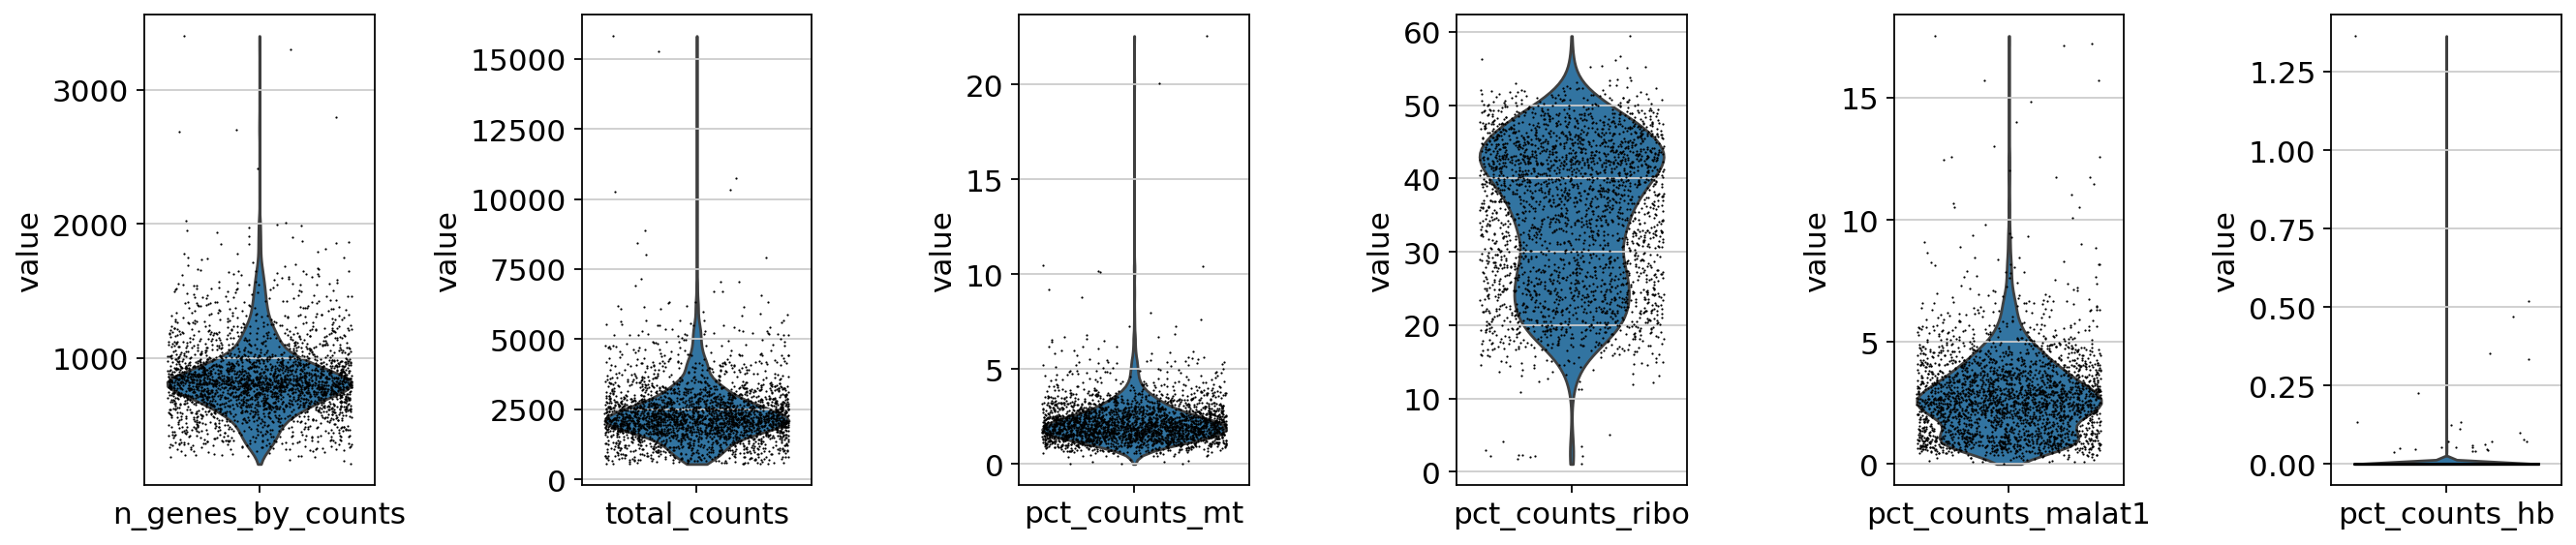

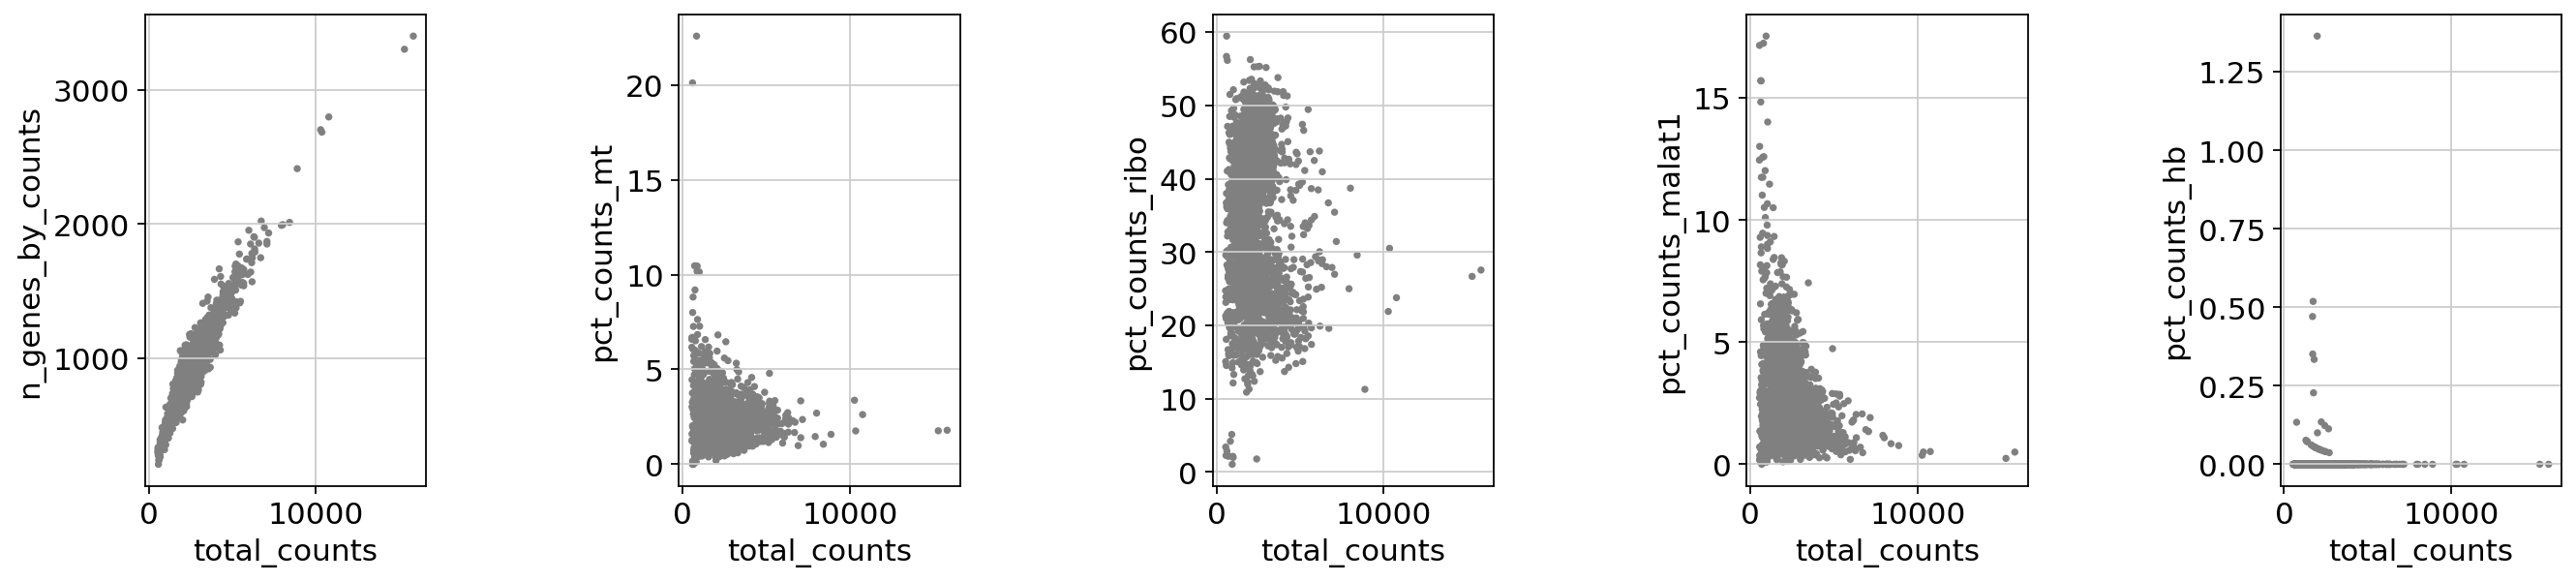

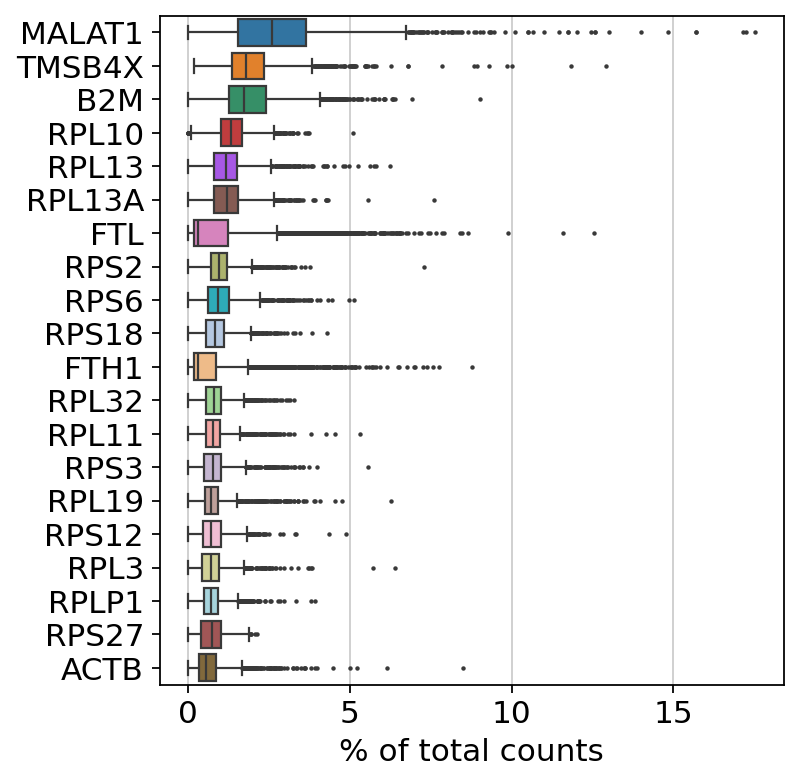

size: 21.666 MB
21.665505
2025-04-24 22:33:12,611 | sctl.pp._qc | INFO |  True keep cells with less than 2500 (n_genes_bycounts) dected genes 
2025-04-24 22:33:12,612 | sctl.pp._qc | INFO |  True keep cells with less than 5 (percent_mt) mitochondiral gene counts 
2025-04-24 22:33:12,613 | sctl.pp._qc | INFO |  True keep cells with greater than 0 (percent_mt) mitochondiral gene counts 
2025-04-24 22:33:12,614 | sctl.pp._qc | INFO |  False keep cells with less than 100 (percent_ribo) ribosomal protein gene counts 
2025-04-24 22:33:12,614 | sctl.pp._qc | INFO |  False keep cells with greater than 0 (percent_ribo) ribosomal protein gene counts 
2025-04-24 22:33:12,615 | sctl.pp._qc | INFO |  False keep cells with less than 100 (percent_hb) hemoglobin protein gene counts 
2025-04-24 22:33:12,616 | sctl.pp._qc | INFO |  False keep cells with greater than 0 (percent_ribo) ribosomal protein gene counts 
2025-04-24 22:33:12,616 | sctl.pp._qc | INFO |  False keep cells with less than 100 (percen

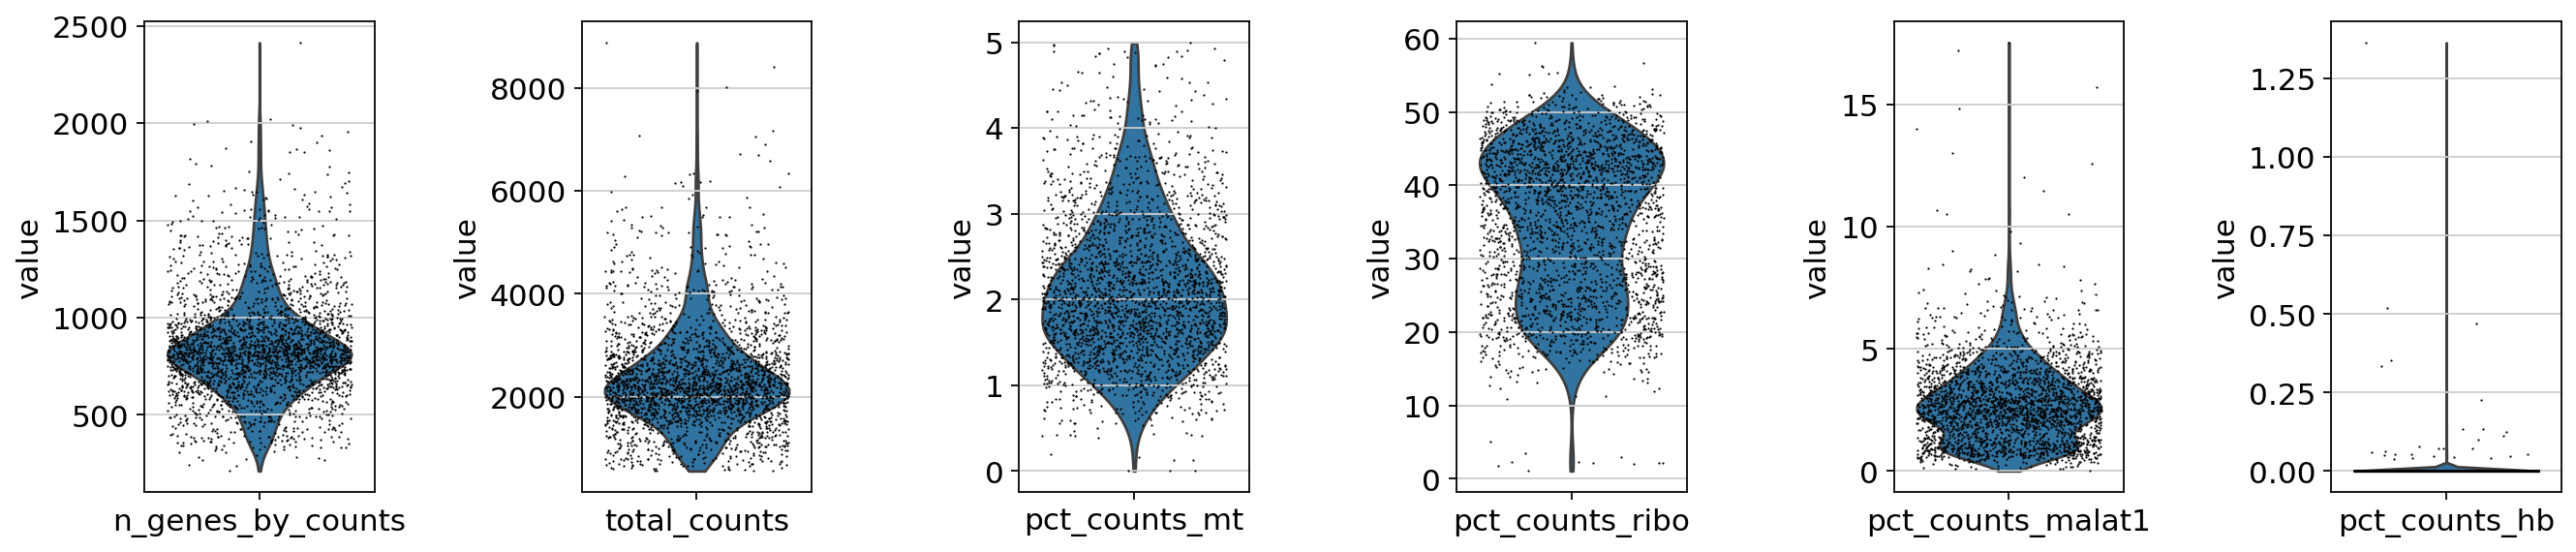

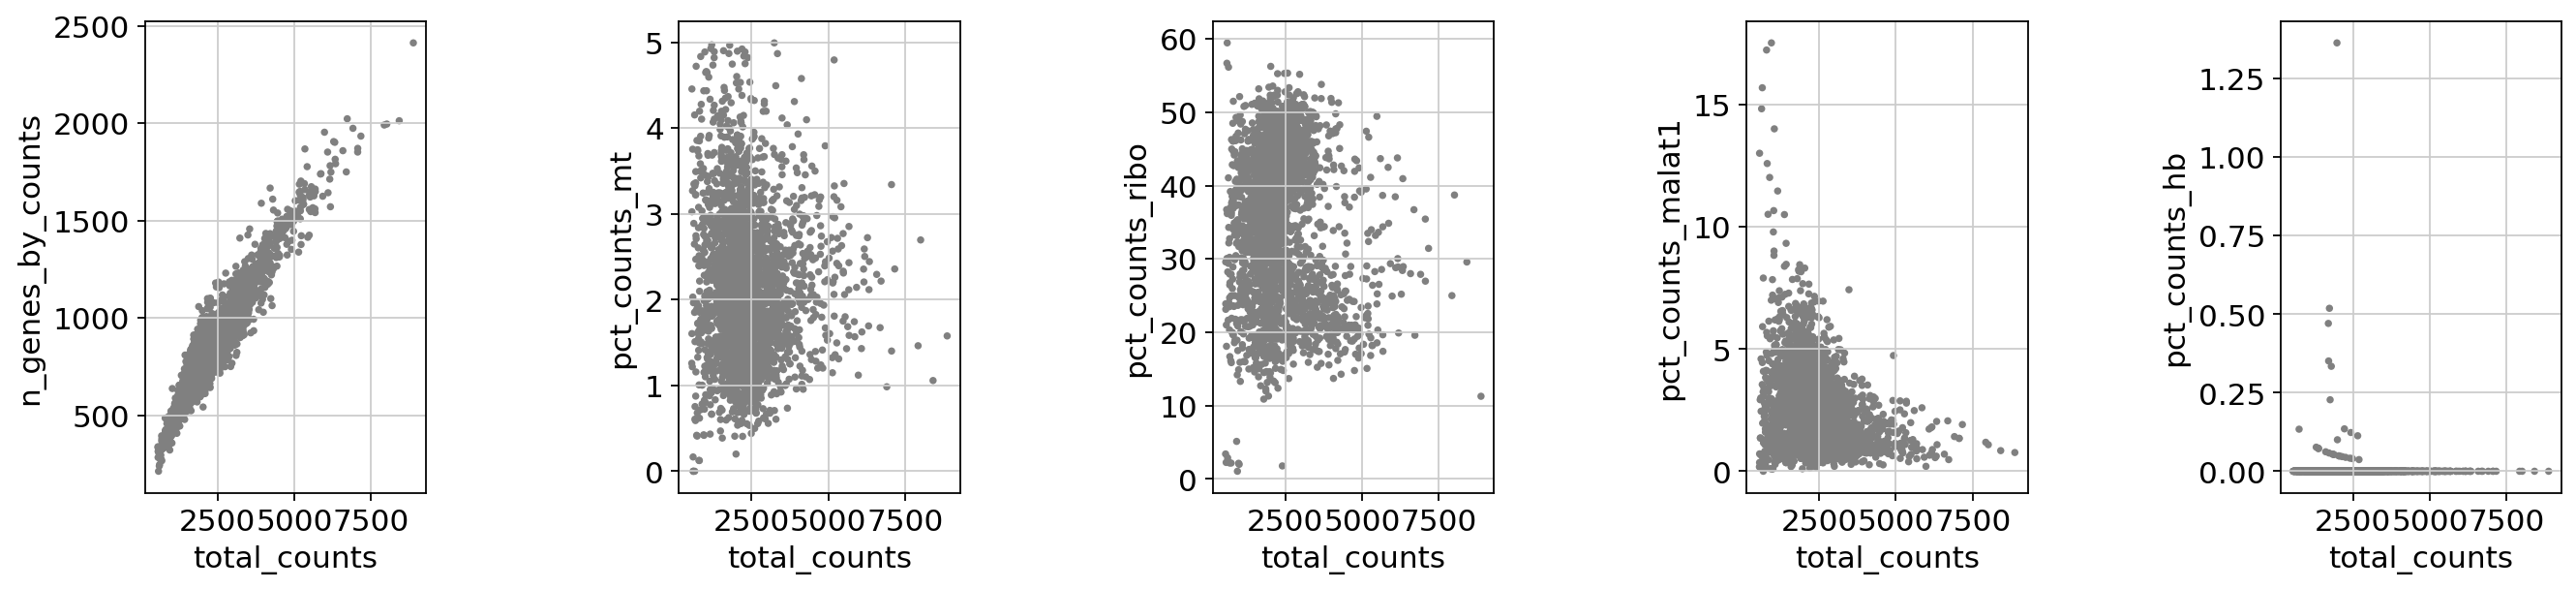

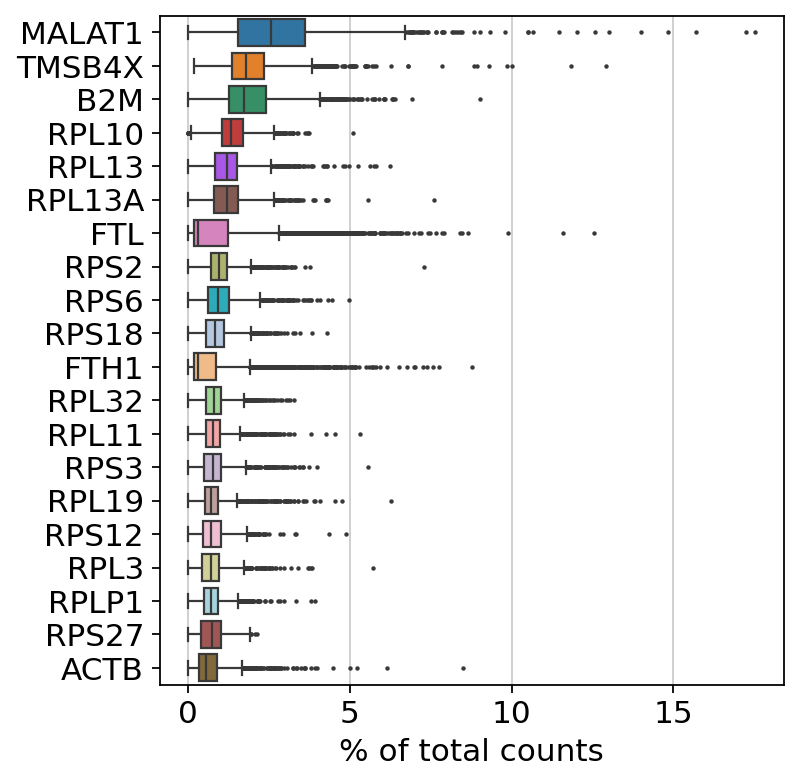

size: 21.304 MB
21.303555
AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'total_counts_malat1', 'pct_counts_malat1'
    var: 'gene_ids', 'n_cells', 'n_counts', 'mt', 'ribo', 'hb', 'malat1', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'parameters'
size: 21.304 MB
21.303555
2025-04-24 22:33:16,918 | sctl.pp._qc | INFO | 
 ####################################################  remove_genes
2025-04-24 22:33:16,919 | sctl.pp._qc | INFO | remove_MALAT1 : False
2025-04-24 22:33:16,919 | sctl.pp._qc | INFO | remove_MT : False
2025-04-24 22:33:16,920 | sctl.pp._qc | INFO | remove_HB : False
2025-04-24 22:33:16,921 | sctl.pp._qc | INFO | remove_RP_SL : False
2025-04-24 22:33:16,921 | sctl.pp._qc | INFO | remove_MRP_SL : False 
2025-04-24 22:33:16,922 | sctl.pp._qc | INFO |  1

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'total_counts_malat1', 'pct_counts_malat1'
    var: 'gene_ids', 'n_cells', 'n_counts', 'mt', 'ribo', 'hb', 'malat1', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'parameters'

In [20]:
%%time
'''

'''
print(sctl.tl.print_size_in_MB(adata))
sc.settings.n_jobs = adata.uns["parameters"]["n_jobs"]

################# do basic filtering of cells and genes
sctl.pp.basic_filitering(adata,**adata.uns["parameters"])
print(f'number of Cells AFTER basic_filitering : {adata.n_obs}')
print(f'number of Genes AFTER basic_filitering : {adata.n_vars}')
print(sctl.tl.print_size_in_MB(adata))
print(adata)
################# annotate and view basic QC stats before addtioanl filteing

#adata=sctl.pp.annotate_n_view_adata_raw_counts(adata)
sctl.pp.annotate_n_view_adata_raw_counts(adata)
print(sctl.tl.print_size_in_MB(adata))


################# filter by QC metrics 
adata=sctl.pp.filter_cells_by_anotated_QC_gene(adata,**adata.uns["parameters"])
print(f'number of Cells AFTER filter_cells_by_anotated_QC_gene : {adata.n_obs}')
print(f'number of Genes AFTER filter_cells_by_anotated_QC_gene: {adata.n_vars}')
print(sctl.tl.print_size_in_MB(adata))
print(adata)
#################  re annoate / re calc  and  after fitlering  by QC metrics   

sctl.pp.annotate_n_view_adata_raw_counts(adata)
print(sctl.tl.print_size_in_MB(adata))
print(adata)


print(sctl.tl.print_size_in_MB(adata))
################# remove specfic "techical" gene groups 
adata=sctl.pp.remove_genes(adata,**adata.uns["parameters"])
print(f'number of Cells AFTER remove_genes : {adata.n_obs}')
print(f'number of Genes AFTER remove_genes: {adata.n_vars}')
print(f'####################################################  plot_qc_metrics after filters and gene removal ')

#  plot_qc_metrics
print(sctl.tl.print_size_in_MB(adata))
adata

size: 21.304 MB
21.303555
2025-04-24 22:33:16,976 | sctl.pp._transform_data | INFO |  running process2scaledPCA adata at start 
 AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'total_counts_malat1', 'pct_counts_malat1'
    var: 'gene_ids', 'n_cells', 'n_counts', 'mt', 'ribo', 'hb', 'malat1', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'parameters'
2025-04-24 22:33:16,977 | sctl.pp._transform_data | INFO | Step 1) library-size correct and Logarithmize (optional) the data 
2025-04-24 22:33:16,978 | sctl.pp._transform_data | INFO | 10000.0 : normalize_total_target_sum 
2025-04-24 22:33:16,978 | sctl.pp._transform_data | INFO | True : Logarithmize (optional) the data 
2025-04-24 22:33:16,979 | sctl.pp._transform_data | INFO | sctl.pp.norm_log() 
2025-04-24 22:33:16,980

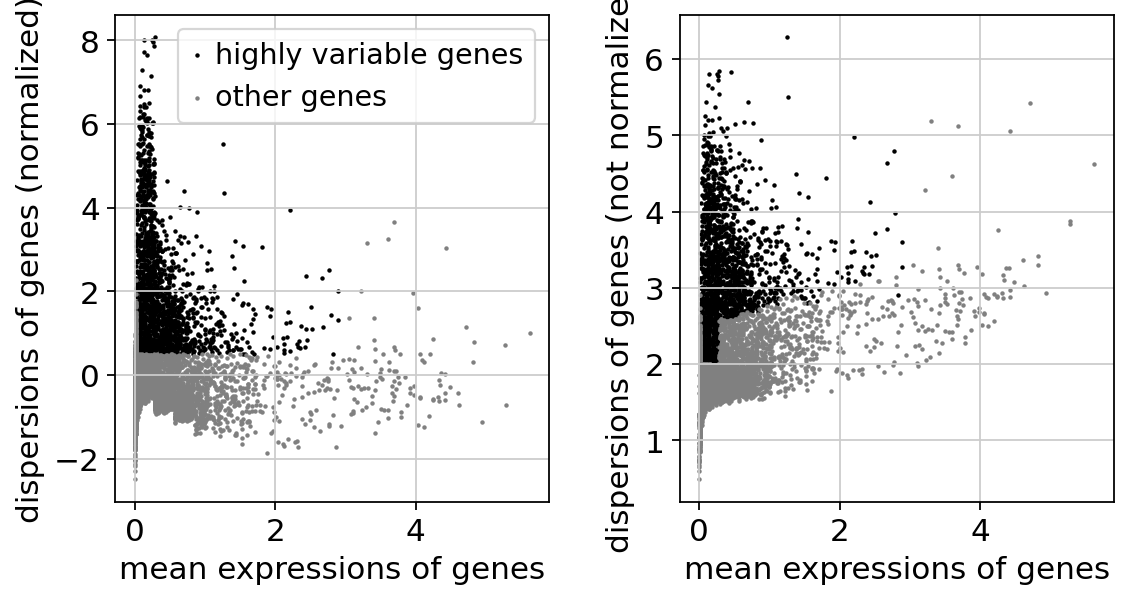

2025-04-24 22:33:17,596 | sctl.pp._transform_data | INFO | 1838 : number of highly varriable genes 
2025-04-24 22:33:17,597 | sctl.pp._transform_data | INFO |  13714 features BEFORE filtering for highly_variable genes
2025-04-24 22:33:17,598 | sctl.pp._transform_data | INFO |  filter_HVG = True ... only highly_variable gene will be kept 
2025-04-24 22:33:17,606 | sctl.pp._transform_data | INFO |  1838 features AFTER filtering for highly_variable genes
2025-04-24 22:33:17,607 | sctl.pp._transform_data | INFO | Step 2) regress_out_anotated_QC_genes (optional)
2025-04-24 22:33:17,608 | sctl.pp._transform_data | INFO | ####################################################  regress_out_anotated_QC_genes 
2025-04-24 22:33:17,608 | sctl.pp._transform_data | INFO | True (optional) regressing out  total_counts 
2025-04-24 22:33:17,609 | sctl.pp._transform_data | INFO | True (optional) regressing out  pct_counts_mt
2025-04-24 22:33:17,610 | sctl.pp._transform_data | INFO | False (optional) regres

/home/ubuntu/miniconda3/envs/sctl/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:710: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


2025-04-24 22:33:17,824 | sctl.pp._transform_data | INFO | running sc.pp.scale(adata,scale_max_std_value=10) 
2025-04-24 22:33:17,924 | sctl.pp._transform_data | INFO | Step 4) cell cycle score (optional)  
2025-04-24 22:33:17,925 | sctl.pp._transform_data | INFO |  True : calculate cell cycle score (optional) 
2025-04-24 22:33:17,926 | sctl.pp._transform_data | INFO |  False : regressing out cell cycle score (optional) 
2025-04-24 22:33:17,927 | sctl.pp._transform_data | INFO | running sctl.pp.calc_cell_cycle_score(adata,organism=human) 
2025-04-24 22:33:17,927 | sctl.pp._transform_data | INFO | ############# WARNING data should be scaled first if planing on regressing out cell cycle score
2025-04-24 22:33:17,928 | sctl.pp._transform_data | INFO | Organism is human, using  human cell cycle genes
2025-04-24 22:33:17,929 | sctl.pp._transform_data | INFO |  there are 43 s_genes   54 g2m_genes  97 cell_cycle_genes
2025-04-24 22:33:17,930 | sctl.pp._transform_data | INFO |  there are 7 cel

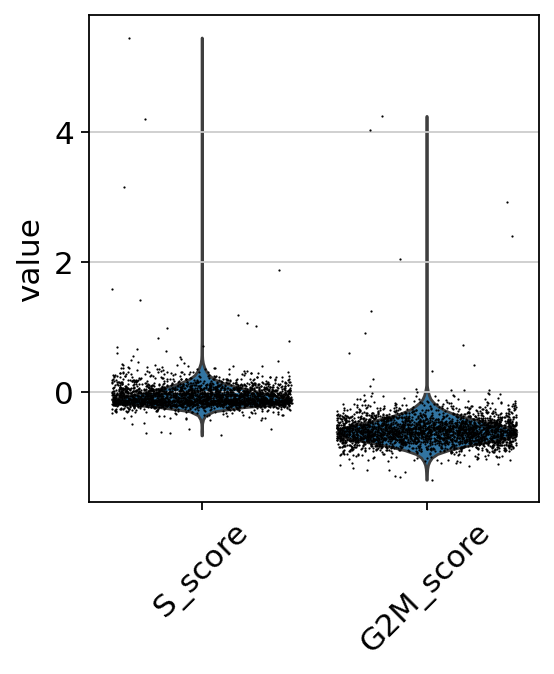

2025-04-24 22:33:18,334 | sctl.pp._transform_data | INFO | Step 5) PCA analysis   
2025-04-24 22:33:18,335 | sctl.pp._transform_data | INFO |  Principal component analysis, results stored in adata.obsm["X_pca"]
2025-04-24 22:33:18,336 | sctl.pp._transform_data | INFO | running sc.tl.pca(adata, svd_solver='arpack')
2025-04-24 22:33:18,336 | sctl.pp._transform_data | INFO | plotting variance ratio sc.pl.pca_variance_ratio(adata, log=True)


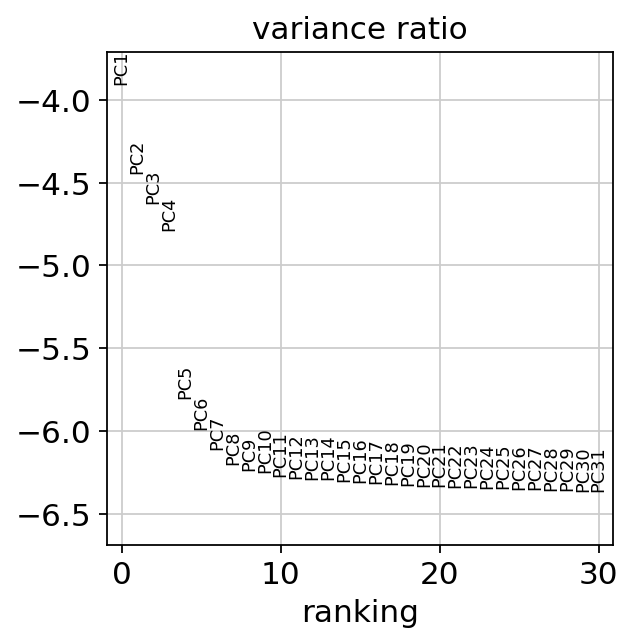

2025-04-24 22:33:21,753 | sctl.pp._transform_data | INFO | Done : process2scaledPCA adata AFTER 
 AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'total_counts_malat1', 'pct_counts_malat1', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'n_cells', 'n_counts', 'mt', 'ribo', 'hb', 'malat1', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'parameters', 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'
size: 24.317 MB
24.317153
size: 24.317 MB
24.317153


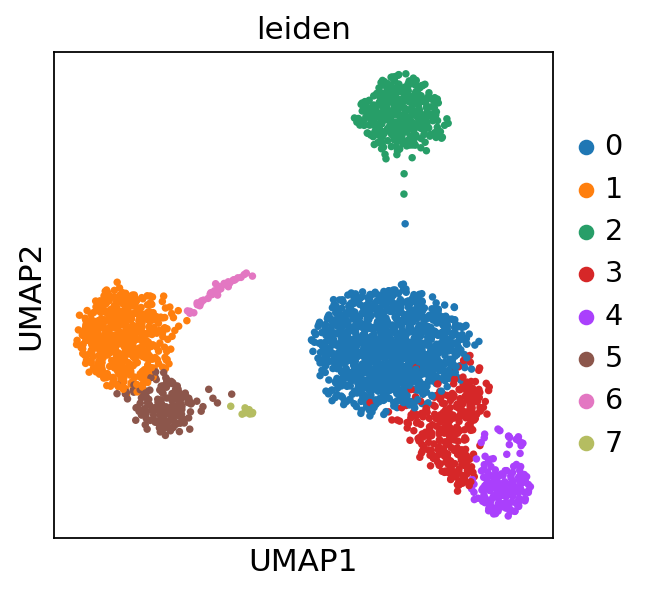

size: 24.984 MB
24.984251
2025-04-24 22:33:38,267 | sctl.pl._plots | INFO |  Average silhoutte score = 0.12454729527235031 for 8 clusters at leiden resolution of 0.9
size: 25.005 MB
25.005355


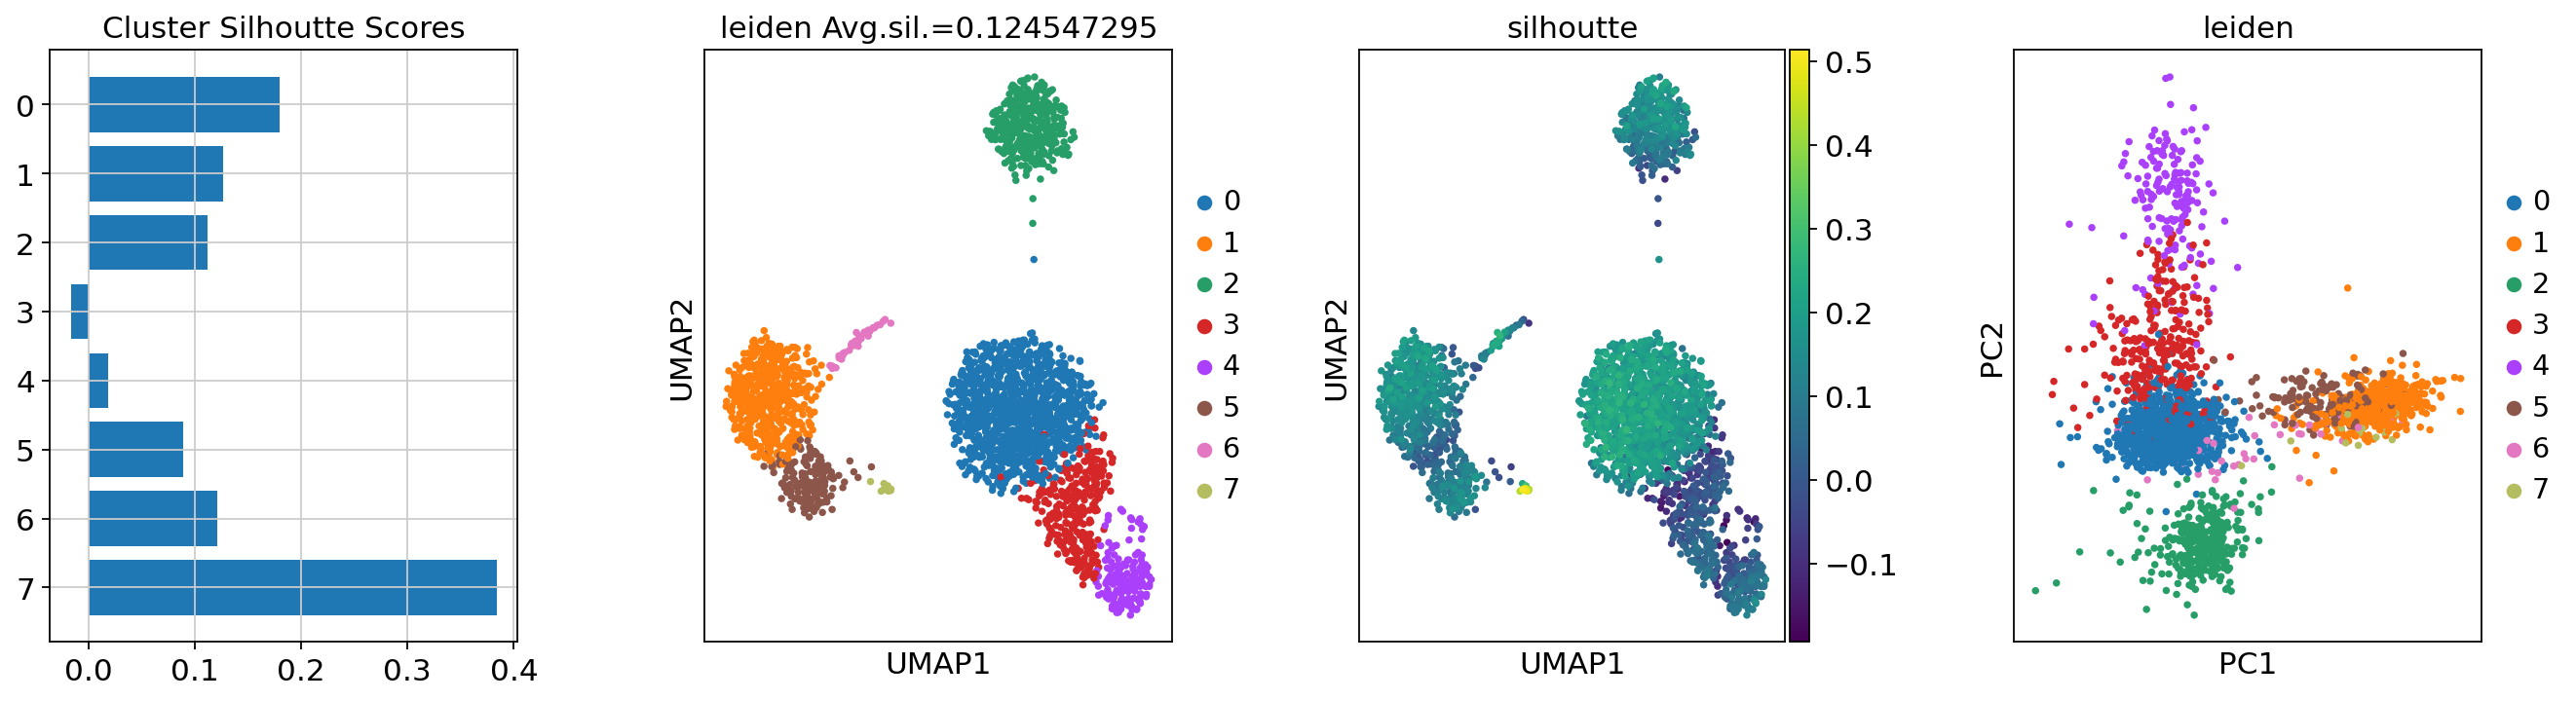

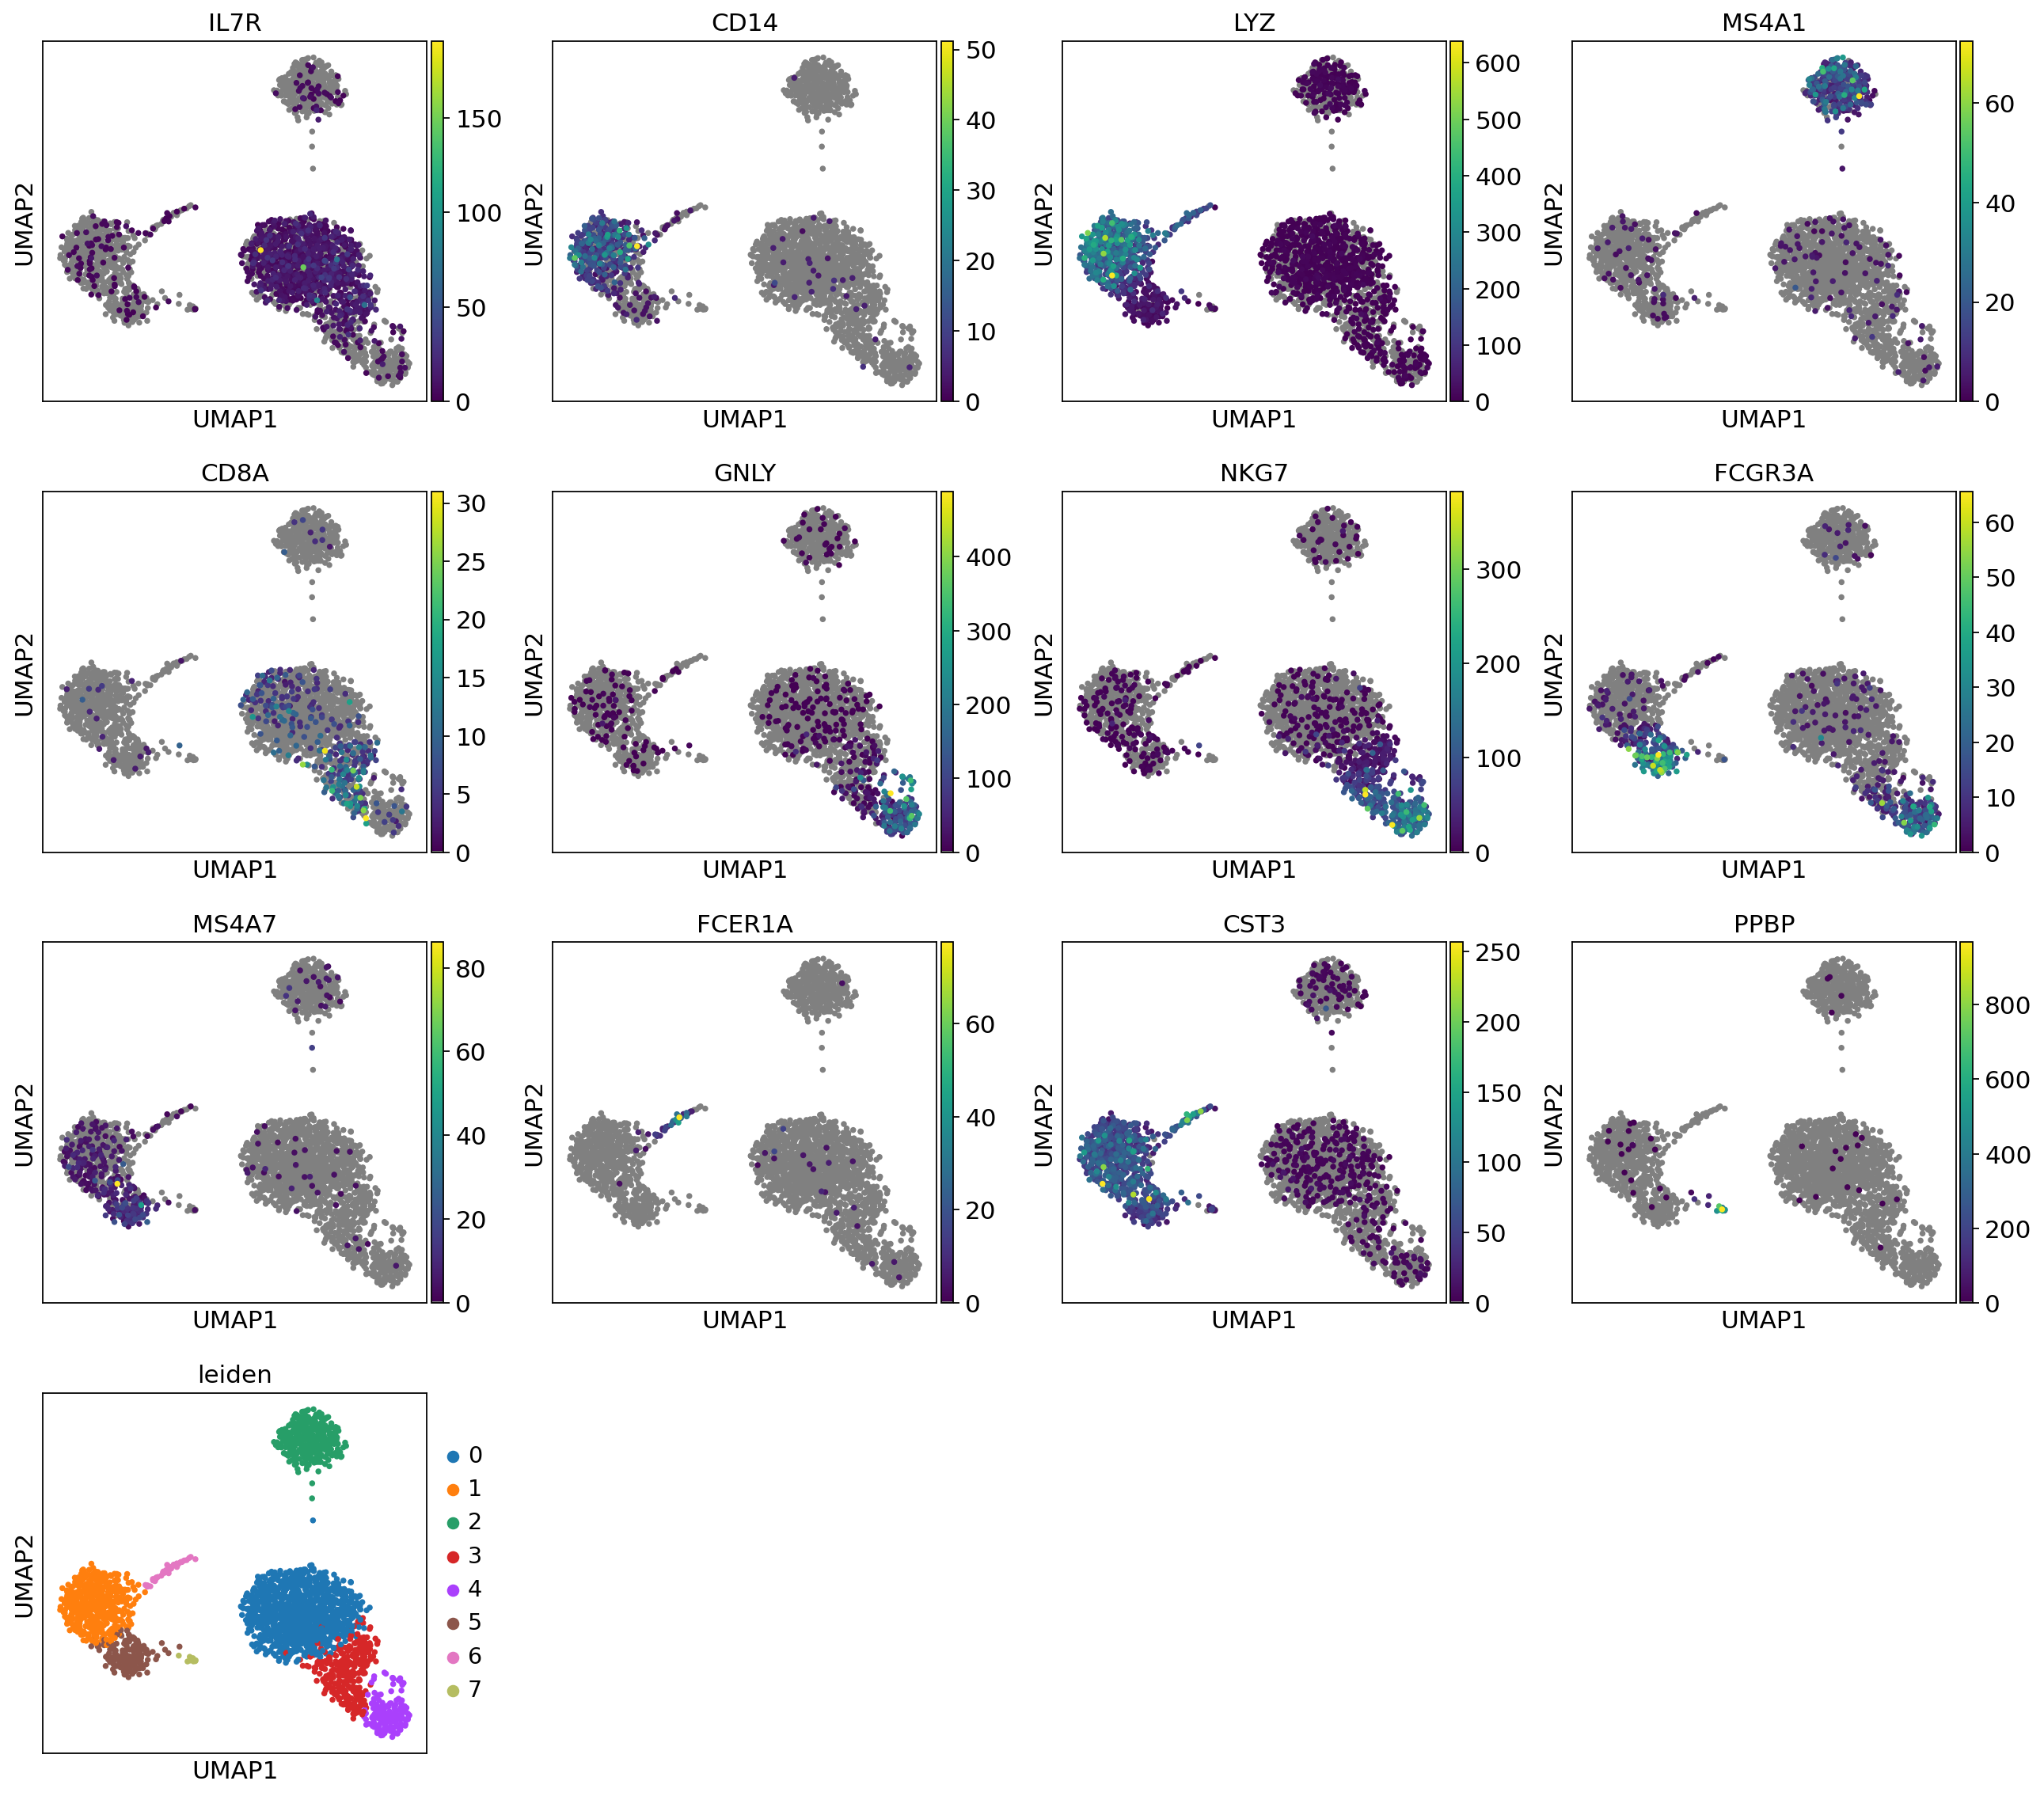

size: 25.005 MB
25.005355
CPU times: user 1min 19s, sys: 867 ms, total: 1min 20s
Wall time: 24.8 s


In [21]:
%%time
print(sctl.tl.print_size_in_MB(adata))
adata=sctl.pp.process2scaledPCA(adata,**adata.uns["parameters"])
print(sctl.tl.print_size_in_MB(adata))


print(sctl.tl.print_size_in_MB(adata))
sctl.pp.leiden_clustering(adata,**adata.uns["parameters"])
print(sctl.tl.print_size_in_MB(adata))

sctl.pl.silhouette_score_n_plot(adata,**adata.uns["parameters"])
print(sctl.tl.print_size_in_MB(adata))

## add a custom color map for the umaps to show zero expression as grey
# Custom colormap where zero values are represented by grey
import matplotlib.colors as mcolors
cmap = mcolors.ListedColormap(['gray'] + list(plt.cm.viridis(np.linspace(0, 1, 256))))
sc.pl.umap(adata, color=adata.uns["parameters"]['umap_marker_gene_list']+['leiden',] , cmap=cmap)
print(sctl.tl.print_size_in_MB(adata))


In [22]:
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'total_counts_malat1', 'pct_counts_malat1', 'S_score', 'G2M_score', 'phase', 'leiden', 'silhoutte'
    var: 'gene_ids', 'n_cells', 'n_counts', 'mt', 'ribo', 'hb', 'malat1', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'parameters', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

size: 25.158 MB
25.158417


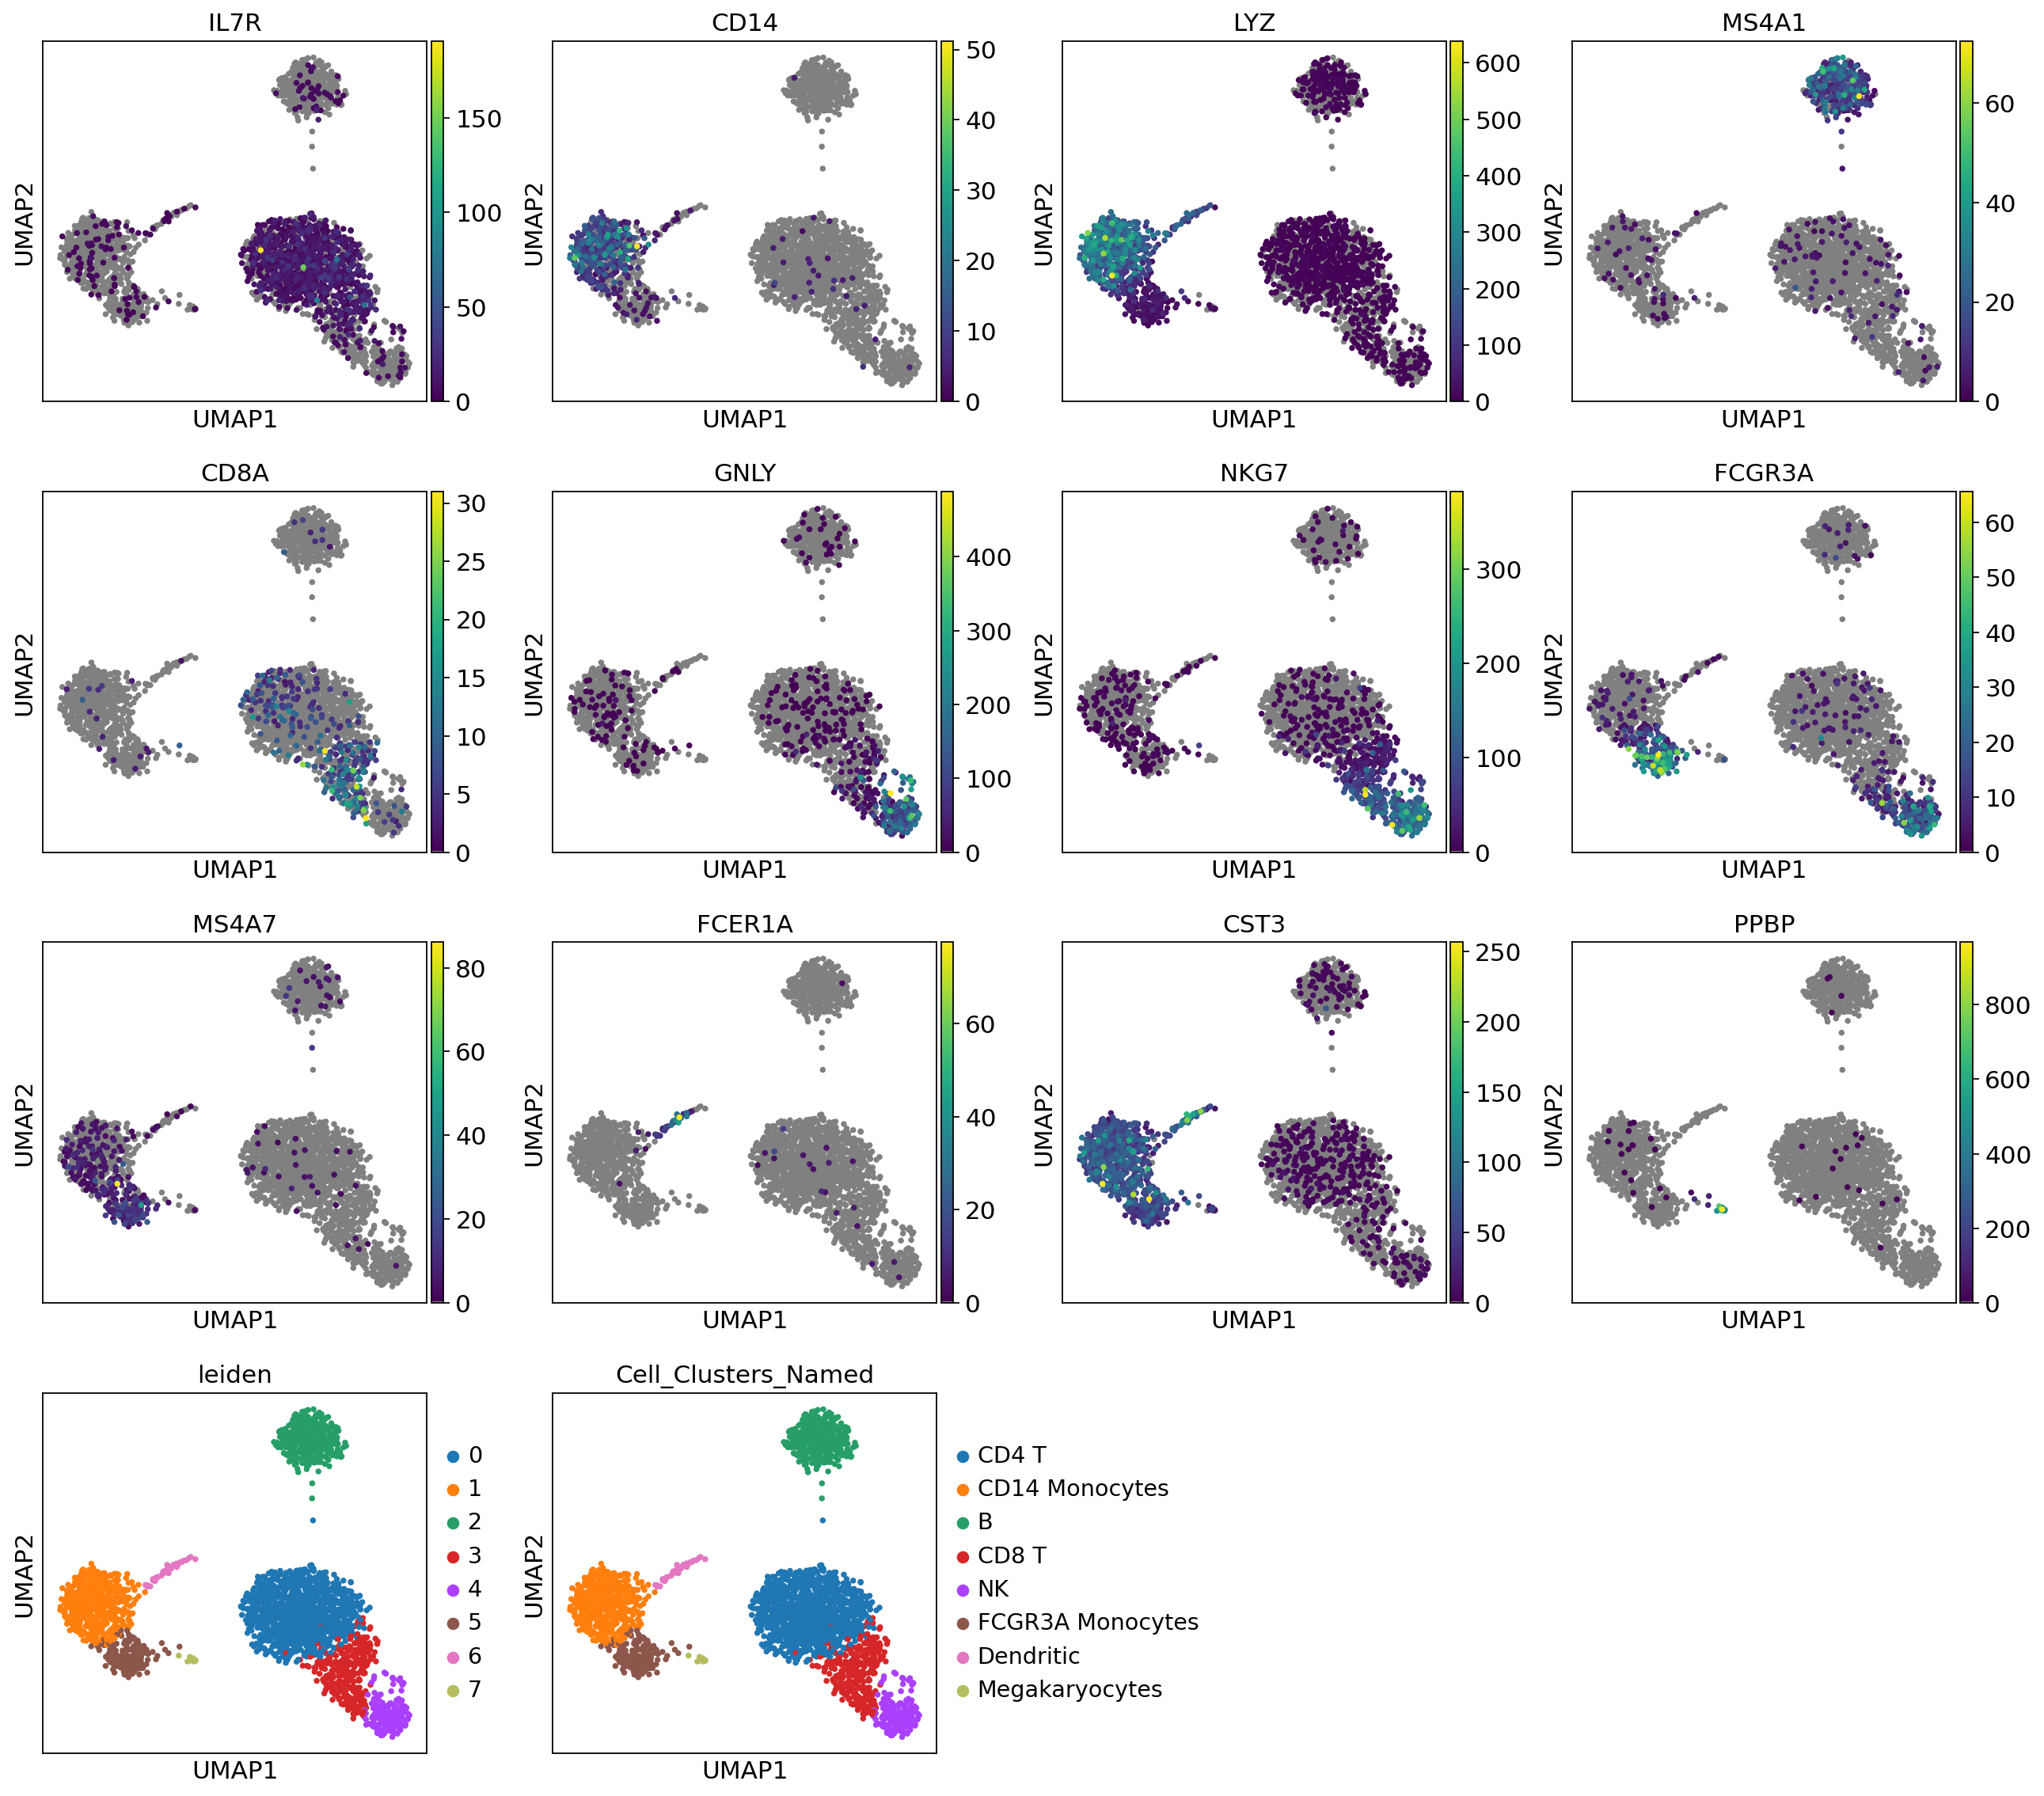

size: 25.009 MB
25.008919
CPU times: user 2.79 s, sys: 196 ms, total: 2.99 s
Wall time: 3.93 s


AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'total_counts_malat1', 'pct_counts_malat1', 'S_score', 'G2M_score', 'phase', 'leiden', 'silhoutte', 'Cell_Clusters_Named'
    var: 'gene_ids', 'n_cells', 'n_counts', 'mt', 'ribo', 'hb', 'malat1', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'parameters', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'Cell_Clusters_Named_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [23]:
%%time
adata.obs['leiden']=adata.obs['leiden'].astype(str)
sctl.pp.rename_leiden_clusters(adata,**adata.uns["parameters"])
print(sctl.tl.print_size_in_MB(adata))


sc.pl.umap(adata, color=adata.uns["parameters"]['umap_marker_gene_list']+['leiden','Cell_Clusters_Named'
] , cmap=cmap)
print(sctl.tl.print_size_in_MB(adata))
adata

In [24]:
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'total_counts_malat1', 'pct_counts_malat1', 'S_score', 'G2M_score', 'phase', 'leiden', 'silhoutte', 'Cell_Clusters_Named'
    var: 'gene_ids', 'n_cells', 'n_counts', 'mt', 'ribo', 'hb', 'malat1', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'parameters', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'Cell_Clusters_Named_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

## now do some Differential Expression Analysis and Gene Set Enrichment Analysis

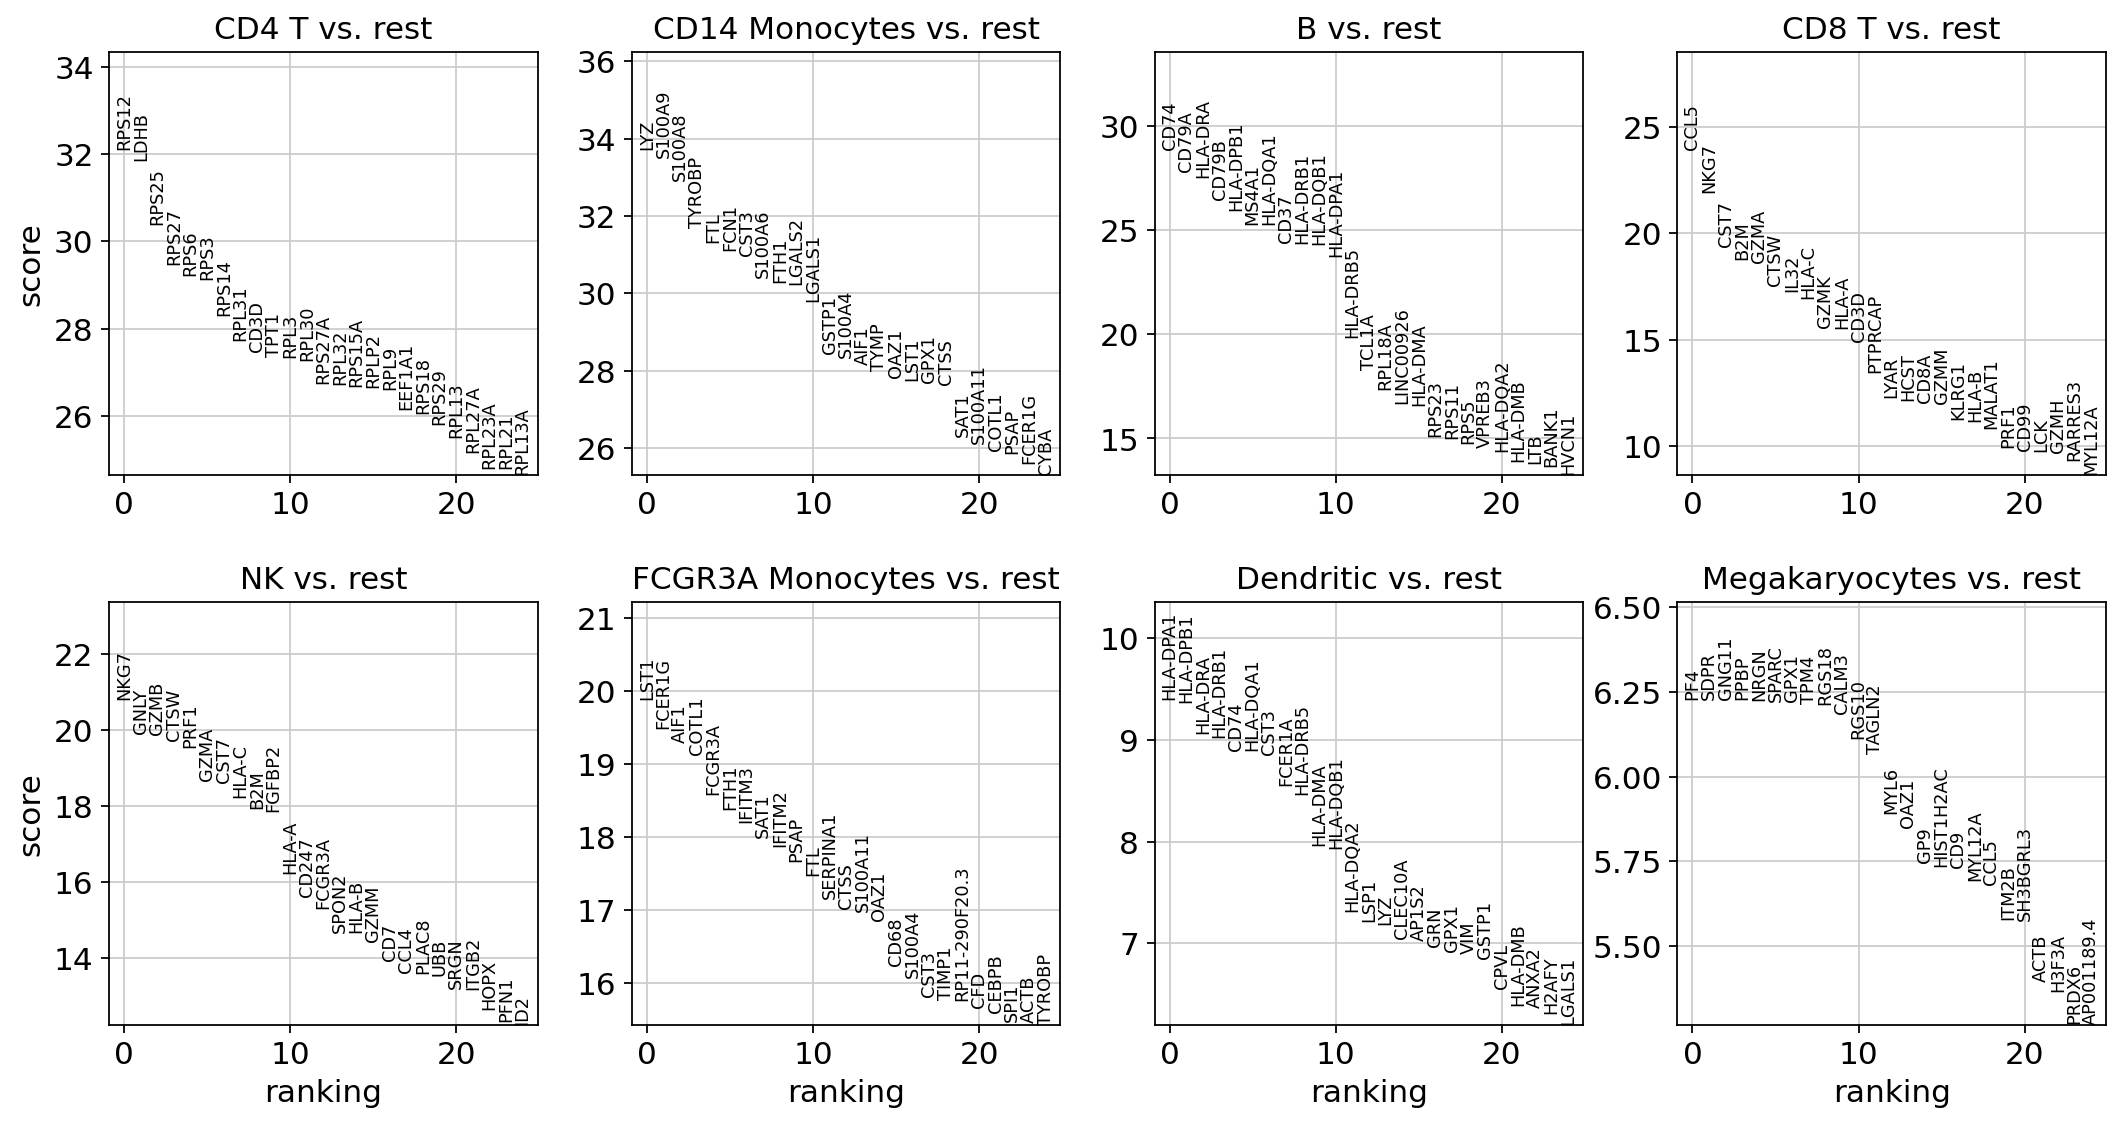

/home/ubuntu/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


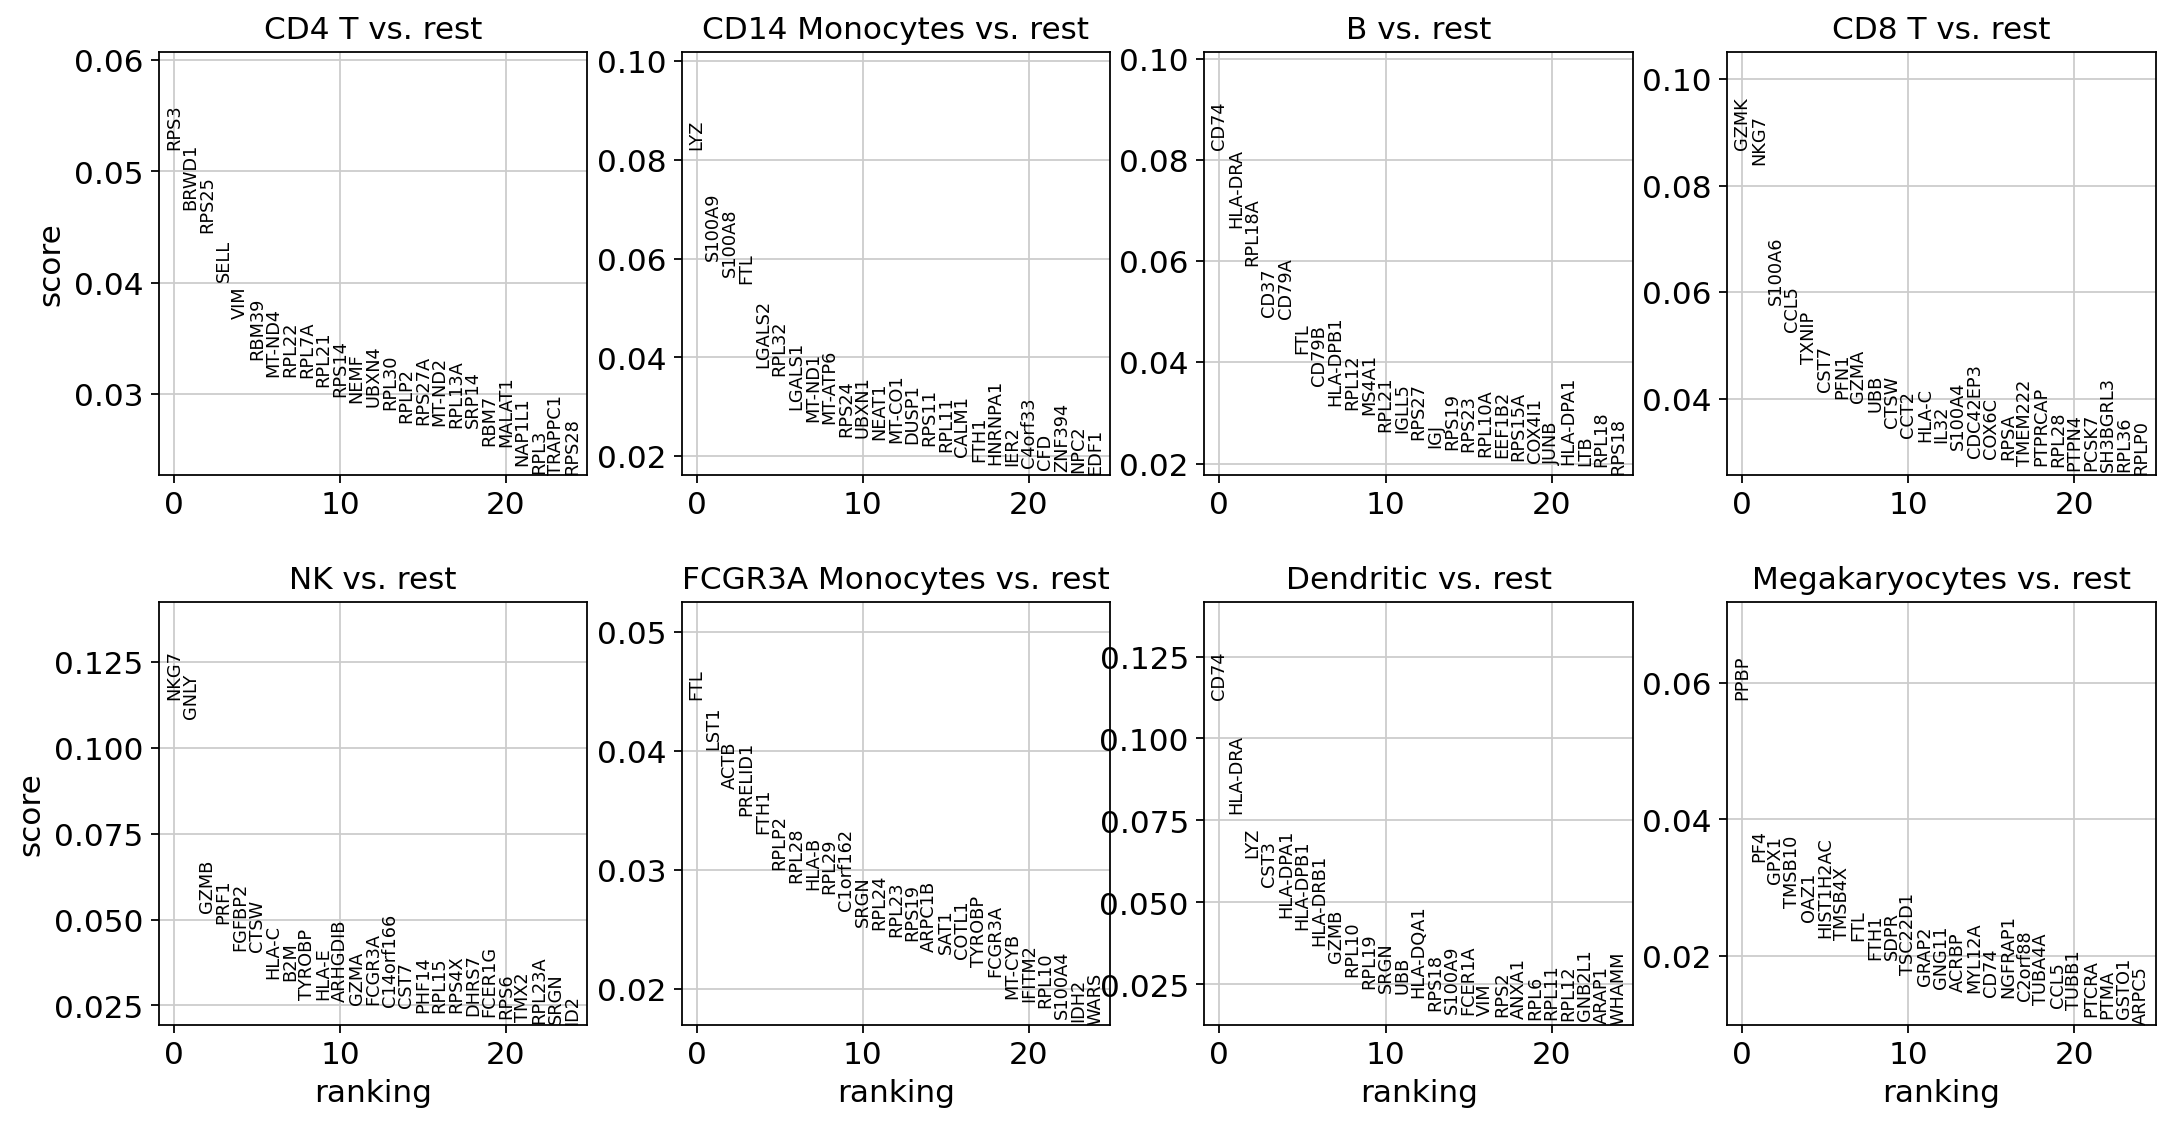

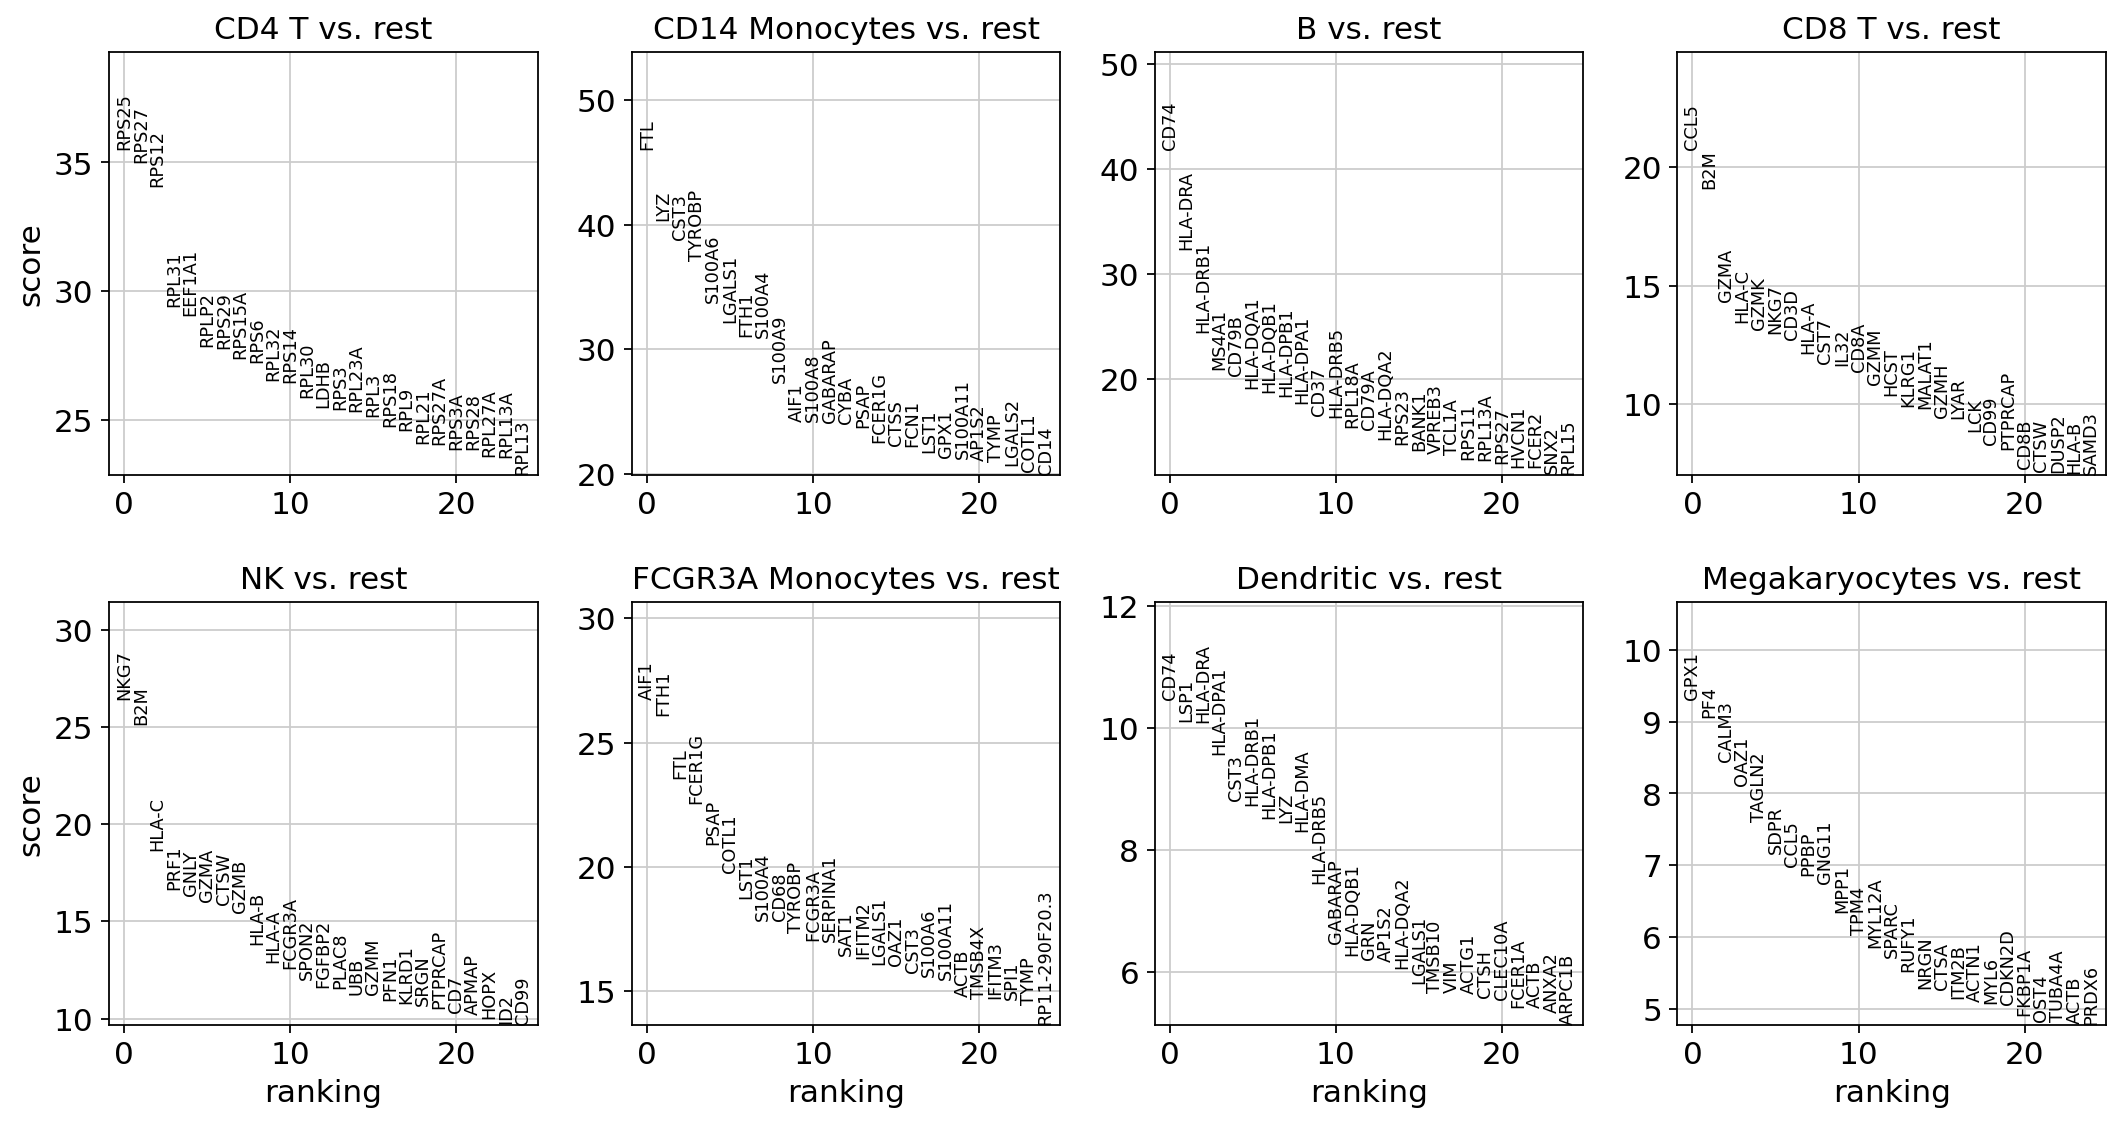

In [25]:
rank_genes_groups_wilcox, rank_genes_groups_logreg,rank_genes_groups_t_test = sctl.tl.rank_genes(adata,
               wilcox=True,logreg=True,t_test=True,rank_use_raw=True,obs_key="Cell_Clusters_Named",**parameters
                 )

In [26]:
rank_genes_groups_wilcox.head(4)

,CD4 T_names,CD4 T_scores,CD4 T_pvals,CD4 T_pvals_adj,CD4 T_logfoldchanges,CD14 Monocytes_names,CD14 Monocytes_scores,CD14 Monocytes_pvals,CD14 Monocytes_pvals_adj,CD14 Monocytes_logfoldchanges,...,Dendritic_names,Dendritic_scores,Dendritic_pvals,Dendritic_pvals_adj,Dendritic_logfoldchanges,Megakaryocytes_names,Megakaryocytes_scores,Megakaryocytes_pvals,Megakaryocytes_pvals_adj,Megakaryocytes_logfoldchanges
0,RPS12,32.109062,3.294801e-226,4.518490e-222,66.597542,LYZ,33.721020,2.844372e-249,3.900772e-245,251.521912,...,HLA-DPA1,9.400656,5.422417e-21,5.205738e-17,71.527679,PF4,6.228046,4.722886e-10,7.725969e-07,244.833679
1,LDHB,31.852373,1.220413e-222,8.368373e-219,14.364327,S100A9,33.517780,2.654880e-246,1.820451e-242,191.717056,...,HLA-DPB1,9.365183,7.591860e-21,5.205738e-17,96.440224,SDPR,6.227681,4.733899e-10,7.725969e-07,123.847191
2,RPS25,30.398174,5.806681e-203,1.592656e-199,33.467358,S100A8,32.928020,8.731315e-238,3.991375e-234,113.062645,...,HLA-DRA,9.059811,1.306768e-19,5.973672e-16,153.435638,GNG11,6.227681,4.733899e-10,7.725969e-07,154.845978
3,RPS27,29.468309,7.336531e-191,1.437331e-187,60.200226,TYROBP,31.714521,9.799314e-221,3.359695e-217,65.280083,...,HLA-DRB1,9.020924,1.865104e-19,6.394510e-16,68.717491,PPBP,6.227316,4.744938e-10,7.725969e-07,673.905945


In [27]:
rank_genes_groups_logreg.head(4)

,CD4 T,CD14 Monocytes,B,CD8 T,NK,FCGR3A Monocytes,Dendritic,Megakaryocytes
0,RPS3,LYZ,CD74,GZMK,NKG7,FTL,CD74,PPBP
1,BRWD1,S100A9,HLA-DRA,NKG7,GNLY,LST1,HLA-DRA,PF4
2,RPS25,S100A8,RPL18A,S100A6,GZMB,ACTB,LYZ,GPX1
3,SELL,FTL,CD37,CCL5,PRF1,PRELID1,CST3,TMSB10


In [28]:
rank_genes_groups_t_test.head(4)

,CD4 T_names,CD4 T_scores,CD4 T_pvals,CD4 T_pvals_adj,CD4 T_logfoldchanges,CD14 Monocytes_names,CD14 Monocytes_scores,CD14 Monocytes_pvals,CD14 Monocytes_pvals_adj,CD14 Monocytes_logfoldchanges,...,Dendritic_names,Dendritic_scores,Dendritic_pvals,Dendritic_pvals_adj,Dendritic_logfoldchanges,Megakaryocytes_names,Megakaryocytes_scores,Megakaryocytes_pvals,Megakaryocytes_pvals_adj,Megakaryocytes_logfoldchanges
0,RPS25,35.509888,3.436019e-221,4.712157e-217,33.467358,FTL,46.021626,4.338669e-201,1.190010e-197,428.119507,...,CD74,10.469278,2.112254e-12,7.048040e-11,183.672165,GPX1,9.312696,7.670559e-07,0.000002,210.964172
1,RPS27,34.985737,6.663381e-220,4.569080e-216,60.200226,LYZ,40.338314,8.558484e-158,8.383647e-155,251.521912,...,LSP1,10.107562,1.771563e-12,5.998818e-11,7.877727,PF4,9.062644,1.026017e-06,0.000003,244.833679
2,RPS12,34.050190,1.667470e-207,7.622559e-204,66.597542,CST3,38.800312,1.692626e-165,1.934389e-162,72.335770,...,HLA-DRA,10.083588,6.040345e-12,1.828638e-10,153.435638,CALM3,8.446024,2.131791e-06,0.000005,40.398705
3,RPL31,29.411518,2.513824e-161,4.309322e-158,28.073187,TYROBP,37.140057,2.851736e-151,2.300512e-148,65.280083,...,HLA-DPA1,9.570313,2.442826e-11,6.594669e-10,71.527679,OAZ1,8.114573,3.203154e-06,0.000008,151.854446


### now some Gene set enrichment analysis based on the top differentially expressed genes
Check the directory for the results of the GSEA analysis

In [29]:
sctl.tl.GSEA_enrichr_all_clusters(test_library_names=['GO_Biological_Process_2021','GO_Cellular_Component_2021','GO_Molecular_Function_2021'],
 top_nth=10,**parameters )

2025-04-24 22:34:29,934 | sctl.tl._functions_4_scanpy | INFO | logreg: the full_table  is 13714 genes long by 8 columns for 8 clusters
2025-04-24 22:34:29,935 | sctl.tl._functions_4_scanpy | INFO | logreg: the foreground list is 1371 genes long
2025-04-24 22:34:29,945 | sctl.tl._functions_4_scanpy | INFO | <CLUSTER 0> for logreg gene rank top 3 background genes ['RPS3', 'BRWD1', 'RPS25'], bottom 3 background genes ['HLA-DRA', 'CD74', 'NKG7'] 
2025-04-24 22:34:29,946 | sctl.tl._functions_4_scanpy | INFO | <CLUSTER 0> for logreg gene rank top 3 foreground genes ['RPS3', 'BRWD1', 'RPS25'], bottom 3 foreground genes ['APEX2', 'CNPY4', 'CCNT2'] 


2025-04-24 22:34:35,440 | sctl.tl._functions_4_scanpy | INFO | <CLUSTER 1> for logreg gene rank top 3 background genes ['LYZ', 'S100A9', 'S100A8'], bottom 3 background genes ['RPL18A', 'RPL28', 'PRELID1'] 
2025-04-24 22:34:35,441 | sctl.tl._functions_4_scanpy | INFO | <CLUSTER 1> for logreg gene rank top 3 foreground genes ['LYZ', 'S100A9', 'S100A8'], bottom 3 foreground genes ['PPP6R1', 'STK11', 'GM2A'] 
2025-04-24 22:34:40,783 | sctl.tl._functions_4_scanpy | INFO | <CLUSTER 2> for logreg gene rank top 3 background genes ['CD74', 'HLA-DRA', 'RPL18A'], bottom 3 background genes ['SELL', 'ACTB', 'LYZ'] 
2025-04-24 22:34:40,784 | sctl.tl._functions_4_scanpy | INFO | <CLUSTER 2> for logreg gene rank top 3 foreground genes ['CD74', 'HLA-DRA', 'RPL18A'], bottom 3 foreground genes ['CENPH', 'RCE1', 'RP11-488C13.5'] 
2025-04-24 22:34:46,161 | sctl.tl._functions_4_scanpy | INFO | <CLUSTER 3> for logreg gene rank top 3 background genes ['GZMK', 'NKG7', 'S100A6'], bottom 3 background genes ['GZM

### END  # use single_cell_python_tools package functions / scanpy wrappers

# do processing using scanpy fucnitons ( functions unwraped )

In [30]:
adata


AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'total_counts_malat1', 'pct_counts_malat1', 'S_score', 'G2M_score', 'phase', 'leiden', 'silhoutte', 'Cell_Clusters_Named'
    var: 'gene_ids', 'n_cells', 'n_counts', 'mt', 'ribo', 'hb', 'malat1', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'parameters', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'Cell_Clusters_Named_colors', 'wilcoxon', 'logreg', 't-test'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [31]:
adata_raw_counts

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    uns: 'parameters'

In [32]:
adata=adata_raw_counts.copy()
adata


AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    uns: 'parameters'

In [33]:
# turn the dictionary values into variables

locals().update(adata.uns["parameters"])


In [34]:
print(f'number of Cells BEFORE Basic Filtering : {adata.n_obs}')
sc.pp.filter_cells(adata, min_genes=filter_cells_min_genes,)  #min_genes=over_n_genes_bycounts
print(f'Filtering cells pp.filter_cells(adata, min_cells=filter_cells_min_genes)  Cells remaining : {adata.n_obs}')
sc.pp.filter_cells(adata,min_counts=filter_cells_min_counts,)  # cells / observations must have min # of coutns
print(f'Filtering cells pp.filter_cells(adata, min_cells=filter_cells_min_counts)  Cells remaining : {adata.n_obs}')
sc.pp.filter_genes(adata, min_cells=filter_genes_min_cells ) #genes must be present in min # of cells / observations
print(f'Filtering genes pp.filter_genes(adata, min_cells=filter_genes_min_cells)  Genes remaining : {adata.n_vars}')
sc.pp.filter_genes(adata, min_counts=filter_genes_min_counts ) #genes must have min # of counts for gene to be kept
print(f'Filtering genes pp.filter_genes(adata, min_cells=filter_genes_min_counts)  Genes remaining :  {adata.n_vars}')

number of Cells BEFORE Basic Filtering : 2700
Filtering cells pp.filter_cells(adata, min_cells=filter_cells_min_genes)  Cells remaining : 2700
Filtering cells pp.filter_cells(adata, min_cells=filter_cells_min_counts)  Cells remaining : 2700
Filtering genes pp.filter_genes(adata, min_cells=filter_genes_min_cells)  Genes remaining : 13714
Filtering genes pp.filter_genes(adata, min_cells=filter_genes_min_counts)  Genes remaining :  13714


<Axes: ylabel='value'>

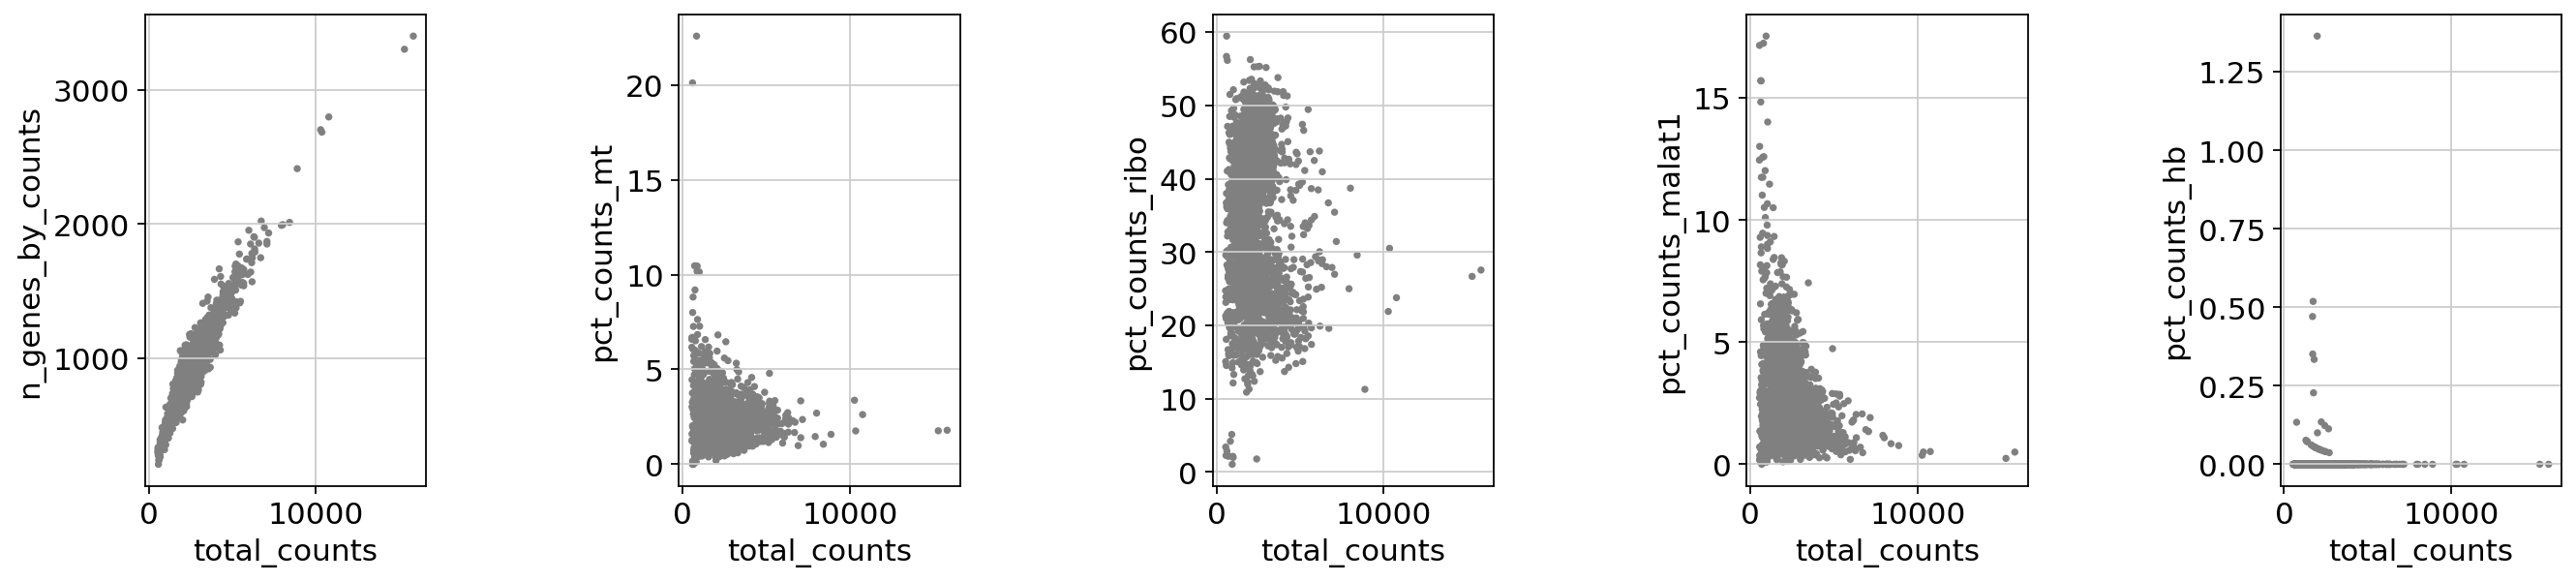

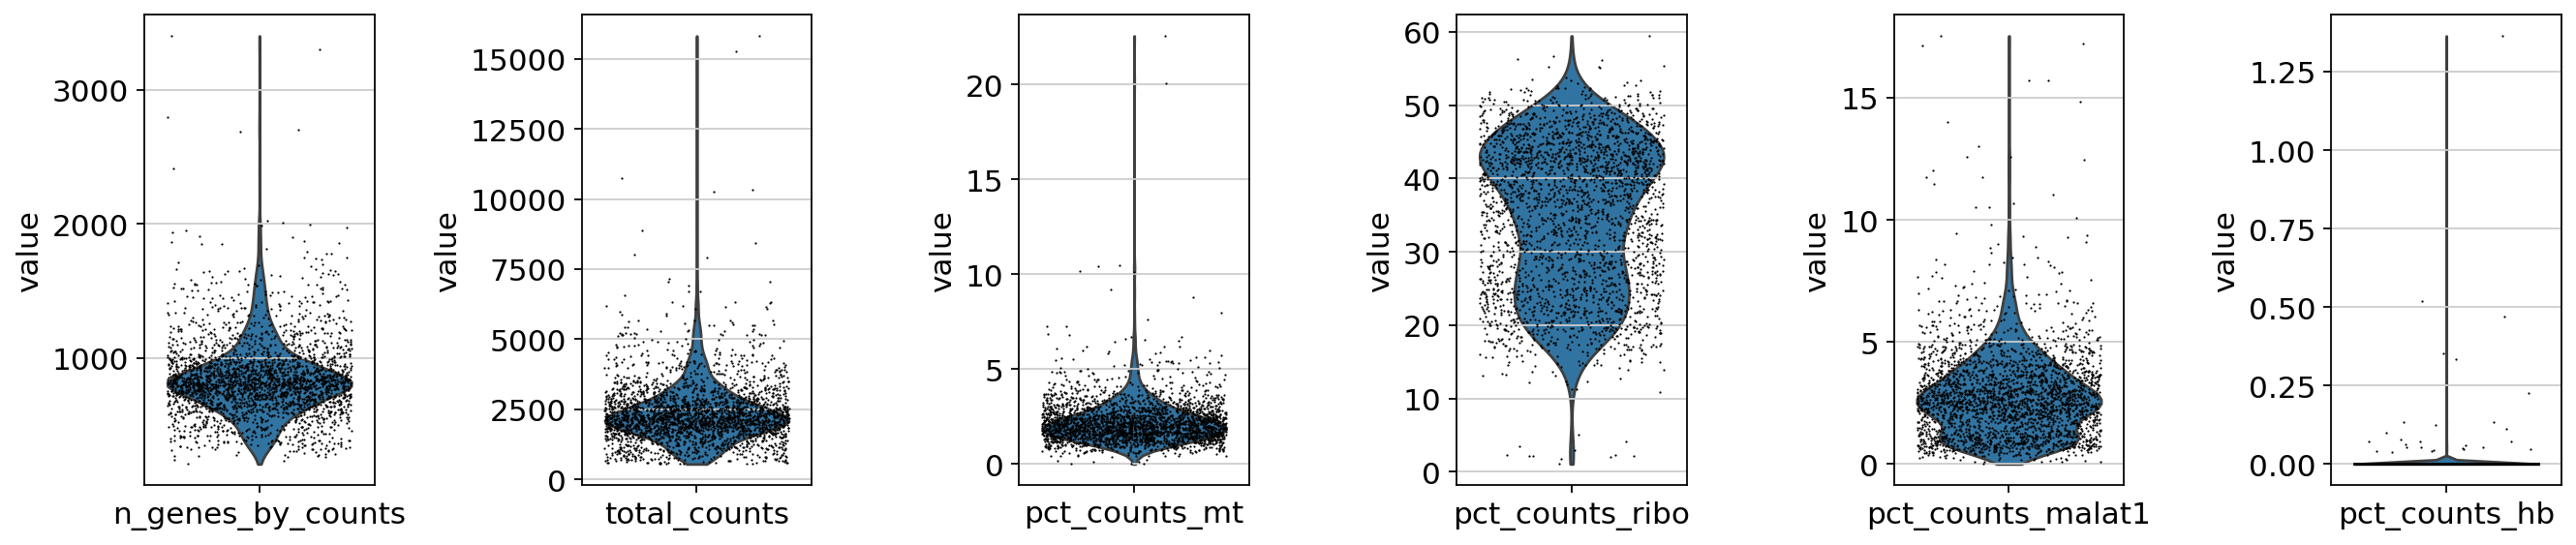

In [35]:

### annotate_QC_genes and calculate_qc_metrics functions

##  annotate_n_view_adata_raw_counts(adata)

# def annotate_QC_genes(adata):
adata.var['mt'] = adata.var_names.str.startswith("MT-")  # mitochondrial genes as 'mt'
adata.var['ribo'] = adata.var_names.str.startswith(("RPS","RPL")) # ribosomal genes genes as 'ribo'
adata.var['hb'] = adata.var_names.str.contains(("^HB[^(P)(S)]")) & ~adata.var_names.str.contains(("HBEGF")) 
# "^HB[^(P)" changed to "^HB[^(P)(S)" and  & ~adata_test.var_names.str.contains(("HBEGF")) added to remove HBS1L and HBEGF which are NOT memoglobin genes
adata.var['malat1'] = adata.var_names.str.contains(("MALAT1"))  # MALAT1 genes as 'malat1'

# def calculate_qc_metrics(adata):
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True) # mitocohndrial  genes
sc.pp.calculate_qc_metrics(adata, qc_vars=['ribo'], percent_top=None, log1p=False, inplace=True) # ribosomal genes
sc.pp.calculate_qc_metrics(adata, qc_vars=['hb'], percent_top=None, log1p=False, inplace=True) # hemoglobin genes.
sc.pp.calculate_qc_metrics(adata, qc_vars=['malat1'], percent_top=None, log1p=False, inplace=True) # MALAT1 gene.

# def plot_QC_metrics_scatter(adata):
figQC, (ax1,ax2,ax3,ax4,ax5) = plt.subplots(1 ,5,figsize=(20,4), gridspec_kw={'wspace':0.9})
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts',ax=ax1, show=False) # plot number of dected genes vs total counts 
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt',ax=ax2, show=False) #percent mt counts vs total counts
sc.pl.scatter(adata, x='total_counts', y='pct_counts_ribo',ax=ax3, show=False) #percent ribo counts vs total counts
sc.pl.scatter(adata, x='total_counts', y='pct_counts_malat1',ax=ax4, show=False) #percent HB counts vs total count
sc.pl.scatter(adata, x='total_counts', y='pct_counts_hb',ax=ax5, show=False) #percent HB counts vs total counts 

#def plot_QC_metrics_violin(adata):
fig1, (ax1,ax2,ax3,ax4,ax5,ax6) = plt.subplots(1 ,6,figsize=(20,4), gridspec_kw={'wspace':0.9})
sc.pl.violin(adata, ['n_genes_by_counts'], jitter=0.4,ax=ax1, show=False)
sc.pl.violin(adata, ['total_counts'], jitter=0.4 ,ax=ax2, show=False)
sc.pl.violin(adata, [ 'pct_counts_mt'], jitter=0.4,ax=ax3, show=False) # mitocohndrial  genes
sc.pl.violin(adata, [ 'pct_counts_ribo'], jitter=0.4,ax=ax4, show=False) # ribosomal genes
sc.pl.violin(adata, [ 'pct_counts_malat1'], jitter=0.4,ax=ax5, show=False) # hemoglobin genes.
sc.pl.violin(adata, [ 'pct_counts_hb'], jitter=0.4,ax=ax6, show=False) # hemoglobin genes.

In [36]:
print(f' {filter_ncount} keep cells with less than {n_genes_bycounts} (n_genes_bycounts) dected genes ')

print(f' {filter_pct_mt} keep cells with less than {percent_mt} (percent_mt) mitochondiral gene counts ')
print(f' {filter_pct_mt} keep cells with greater than {over_percent_mt} (percent_mt) mitochondiral gene counts ')

print(f' {filter_pct_ribo} keep cells with less than {percent_ribo} (percent_ribo) ribosomal protein gene counts ')
print(f' {filter_pct_ribo} keep cells with greater than {over_percent_ribo} (percent_ribo) ribosomal protein gene counts ')

print(f' {filter_pct_hb} keep cells with less than {percent_hb} (percent_hb) hemoglobin protein gene counts ')
print(f' {filter_pct_hb} keep cells with greater than {over_percent_hb} (percent_ribo) ribosomal protein gene counts ')

print(f' {filter_pct_malat1} keep cells with less than {percent_malat1} (percent_hb) hemoglobin protein gene counts ')
print(f' {filter_pct_malat1} keep cells with greater than {over_percent_malat1} (percent_ribo) ribosomal protein gene counts ')

# Actually do the filtering by slicing the `AnnData` object.
print(f'number of Cells BEFORE pct Filtering : {adata.n_obs}')
if filter_ncount ==True:
    adata = adata[adata.obs.n_genes_by_counts <= n_genes_bycounts, :].copy()  # by n_genes_bycounts
    print(f'number of Cells AFTER n_genes_bycounts Filtering : {adata.n_obs}')
if filter_pct_mt ==True:
    adata = adata[adata.obs.pct_counts_mt <= percent_mt, :].copy()   # by percent_mt
    print(f'number of Cells AFTER percent_mt Filtering : {adata.n_obs}')
    adata = adata[adata.obs.pct_counts_mt >= over_percent_mt, :].copy()    # by percent_mt
    print(f'number of Cells AFTER over_percent_mt Filtering : {adata.n_obs}')
if filter_pct_ribo ==True:
    adata = adata[adata.obs.pct_counts_ribo <= percent_ribo, :].copy()   # by percent_ribo
    print(f'number of Cells AFTER percent_ribo Filtering : {adata.n_obs}')
    adata = adata[adata.obs.pct_counts_ribo >= over_percent_ribo, :].copy()    # by percent_ribo
    print(f'number of Cells AFTER over_percent_ribo Filtering : {adata.n_obs}')
if filter_pct_hb ==True:
    adata = adata[adata.obs.pct_counts_hb <= percent_hb, :].copy()    # by percent_hb
    print(f'number of Cells AFTER percent_hb Filtering : {adata.n_obs}')
    adata = adata[adata.obs.pct_counts_hb >= over_percent_hb, :].copy()    # by percent_hb
    print(f'number of Cells AFTER over_percent_hb Filtering : {adata.n_obs}')
if filter_pct_malat1 ==True:
    adata = adata[adata.obs.pct_counts_malat1 <= percent_malat1, :].copy()    # by percent_hb
    print(f'number of Cells AFTER percent_malat1 Filtering : {adata.n_obs}')
    adata = adata[adata.obs.pct_counts_malat1 >= over_percent_malat1, :].copy()    # by percent_hb
    print(f'number of Cells AFTER over_percent_malat1 Filtering : {adata.n_obs}')        


 True keep cells with less than 2500 (n_genes_bycounts) dected genes 
 True keep cells with less than 5 (percent_mt) mitochondiral gene counts 
 True keep cells with greater than 0 (percent_mt) mitochondiral gene counts 
 False keep cells with less than 100 (percent_ribo) ribosomal protein gene counts 
 False keep cells with greater than 0 (percent_ribo) ribosomal protein gene counts 
 False keep cells with less than 100 (percent_hb) hemoglobin protein gene counts 
 False keep cells with greater than 0 (percent_ribo) ribosomal protein gene counts 
 False keep cells with less than 100 (percent_hb) hemoglobin protein gene counts 
 False keep cells with greater than 0 (percent_ribo) ribosomal protein gene counts 
number of Cells BEFORE pct Filtering : 2700
number of Cells AFTER n_genes_bycounts Filtering : 2695
number of Cells AFTER percent_mt Filtering : 2638
number of Cells AFTER over_percent_mt Filtering : 2638


In [37]:



### Remove gene sets  on off switches
print(f'####################################################  remove_genes')
print(f'remove_MALAT1 {remove_MALAT1}')
print(f'remove_MT {remove_MT}')
print(f'remove_HB {remove_HB}')
print(f'remove_RP_SL {remove_RP_SL}')
print(f'remove_MRP_SL {remove_MRP_SL} ')


print(f' BEFORE filtering for specific gene : number of Cells {adata.n_obs}, number of genes {adata.n_vars}')

nothing = adata.var_names.str.startswith('NO_GENES_HAVE_THIS_NAME')
remove = np.add(nothing, nothing)
print(len((nothing)))

if remove_MALAT1==True:
    malat1 = adata.var_names.str.startswith('MALAT1')
    remove = np.add(remove, malat1)
# we need to redefine the mito_genes since they were first 
# calculated on the full object before removing low expressed genes.

if remove_MT==True:
    mito_genes = adata.var_names.str.startswith('MT-')
    remove = np.add(remove,mito_genes)
if remove_HB==True:
    hb_genes = (adata.var_names.str.startswith('HB')& ~adata.var_names.str.contains(("HBEGF"))  & ~adata.var_names.str.contains(("HBS1L"))  & ~adata.var_names.str.contains(("HBP1"))) # HBEGF,HBS1L, HBP1 not a hemeoglobin genes 
    remove = np.add(remove,hb_genes)
if remove_RP_SL==True:
    RP_SL_genes = adata.var_names.str.startswith(("RPS","RPL"))
    remove = np.add(remove,RP_SL_genes )
if remove_MRP_SL==True:
    MRP_SL_genes = adata.var_names.str.startswith(("MRPS","MRPL"))
    remove = np.add(remove,MRP_SL_genes )    

keep = np.invert(remove)
adata = adata[:,keep].copy()

print(f' AFTER filtering for specific gene : number of Cells {adata.n_obs}, number of genes {adata.n_vars}')

####################################################  remove_genes
remove_MALAT1 False
remove_MT False
remove_HB False
remove_RP_SL False
remove_MRP_SL False 
 BEFORE filtering for specific gene : number of Cells 2638, number of genes 13714
13714
 AFTER filtering for specific gene : number of Cells 2638, number of genes 13714


<Axes: ylabel='value'>

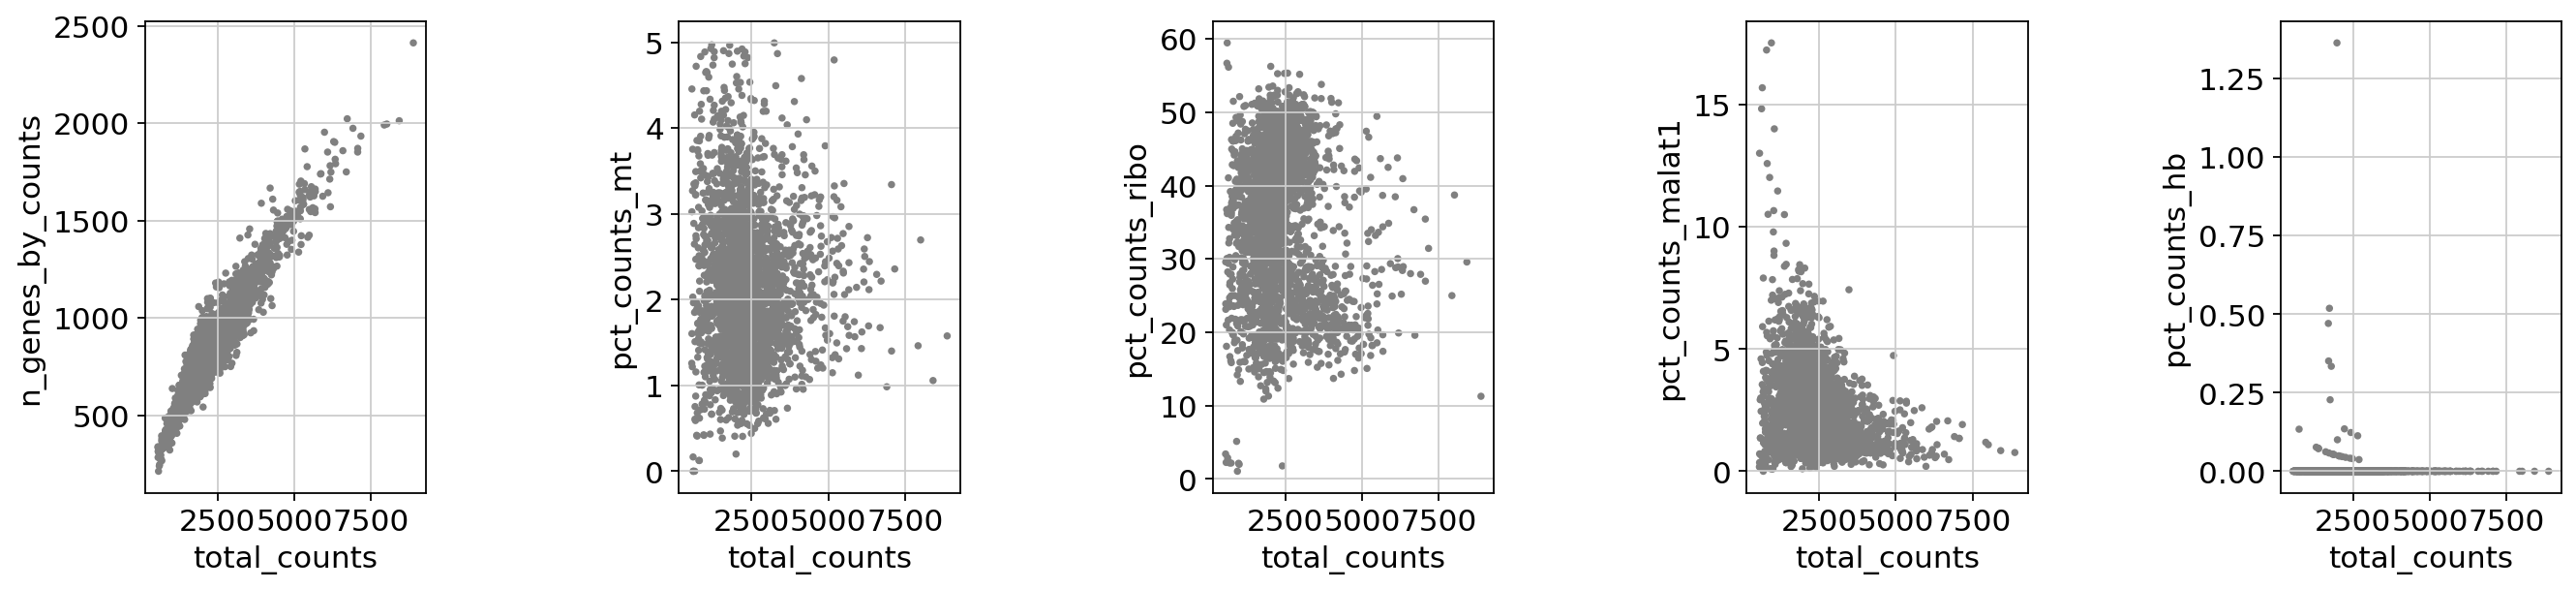

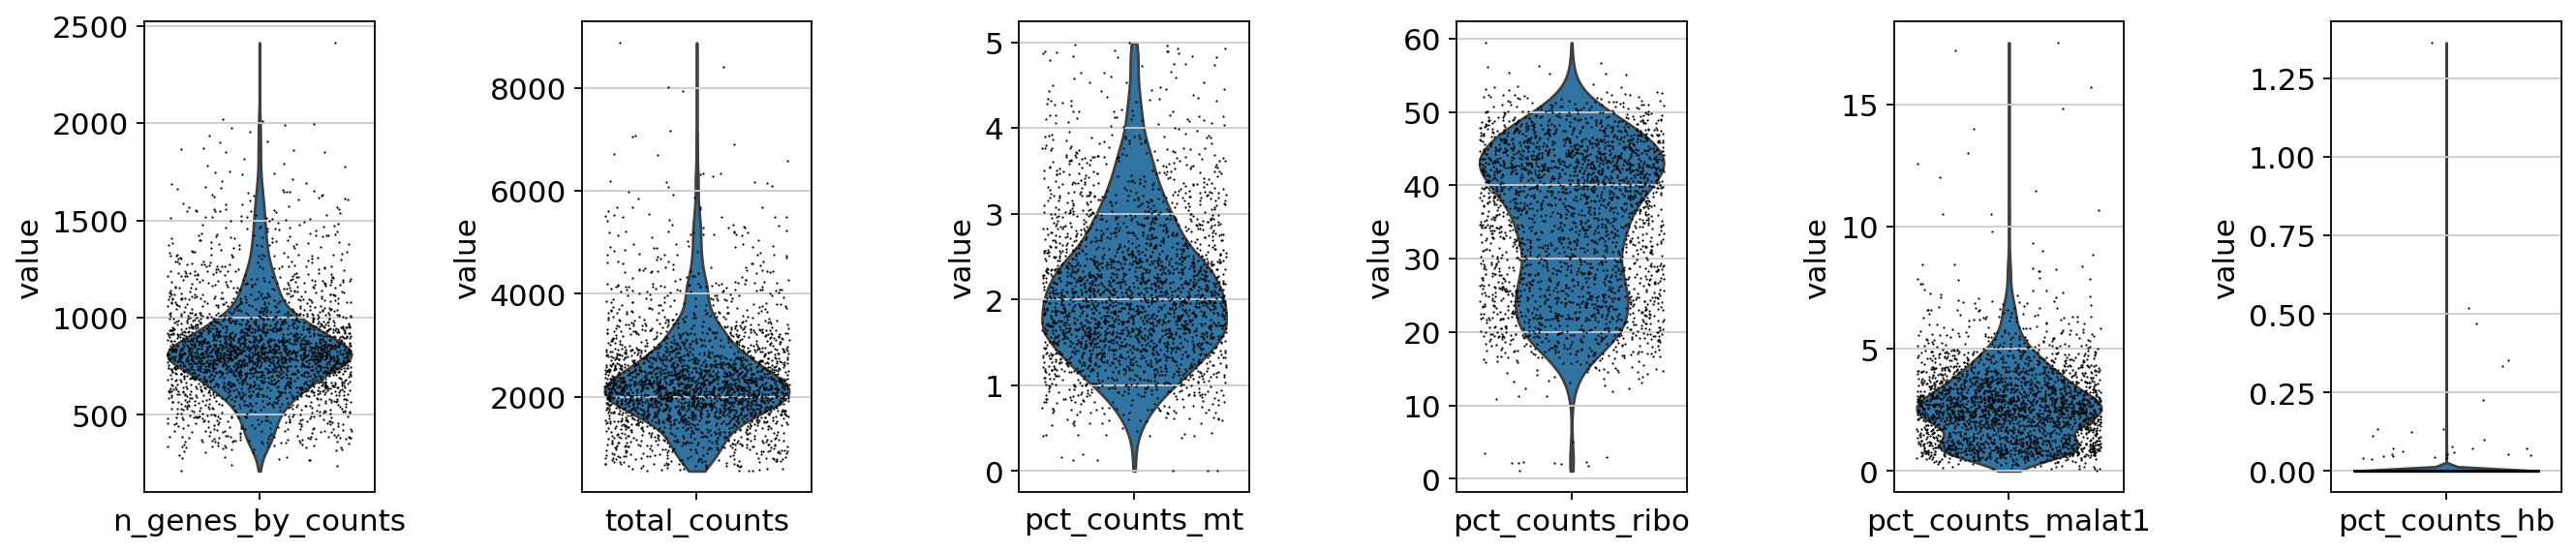

In [38]:
### now repeat this step after filtering

### annotate_QC_genes and calculate_qc_metrics functions

##  annotate_n_view_adata_raw_counts(adata)

# def annotate_QC_genes(adata):
adata.var['mt'] = adata.var_names.str.startswith("MT-")  # mitochondrial genes as 'mt'
adata.var['ribo'] = adata.var_names.str.startswith(("RPS","RPL")) # ribosomal genes genes as 'ribo'
adata.var['hb'] = adata.var_names.str.contains(("^HB[^(P)(S)]")) & ~adata.var_names.str.contains(("HBEGF")) 
# "^HB[^(P)" changed to "^HB[^(P)(S)" and  & ~adata_test.var_names.str.contains(("HBEGF")) added to remove HBS1L and HBEGF which are NOT memoglobin genes
adata.var['malat1'] = adata.var_names.str.contains(("MALAT1"))  # MALAT1 genes as 'malat1'

# def calculate_qc_metrics(adata):
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True) # mitocohndrial  genes
sc.pp.calculate_qc_metrics(adata, qc_vars=['ribo'], percent_top=None, log1p=False, inplace=True) # ribosomal genes
sc.pp.calculate_qc_metrics(adata, qc_vars=['hb'], percent_top=None, log1p=False, inplace=True) # hemoglobin genes.
sc.pp.calculate_qc_metrics(adata, qc_vars=['malat1'], percent_top=None, log1p=False, inplace=True) # MALAT1 gene.

# def plot_QC_metrics_scatter(adata):
figQC, (ax1,ax2,ax3,ax4,ax5) = plt.subplots(1 ,5,figsize=(20,4), gridspec_kw={'wspace':0.9})
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts',ax=ax1, show=False) # plot number of dected genes vs total counts 
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt',ax=ax2, show=False) #percent mt counts vs total counts
sc.pl.scatter(adata, x='total_counts', y='pct_counts_ribo',ax=ax3, show=False) #percent ribo counts vs total counts
sc.pl.scatter(adata, x='total_counts', y='pct_counts_malat1',ax=ax4, show=False) #percent HB counts vs total count
sc.pl.scatter(adata, x='total_counts', y='pct_counts_hb',ax=ax5, show=False) #percent HB counts vs total counts 

#def plot_QC_metrics_violin(adata):
fig1, (ax1,ax2,ax3,ax4,ax5,ax6) = plt.subplots(1 ,6,figsize=(20,4), gridspec_kw={'wspace':0.9})
sc.pl.violin(adata, ['n_genes_by_counts'], jitter=0.4,ax=ax1, show=False)
sc.pl.violin(adata, ['total_counts'], jitter=0.4 ,ax=ax2, show=False)
sc.pl.violin(adata, [ 'pct_counts_mt'], jitter=0.4,ax=ax3, show=False) # mitocohndrial  genes
sc.pl.violin(adata, [ 'pct_counts_ribo'], jitter=0.4,ax=ax4, show=False) # ribosomal genes
sc.pl.violin(adata, [ 'pct_counts_malat1'], jitter=0.4,ax=ax5, show=False) # hemoglobin genes.
sc.pl.violin(adata, [ 'pct_counts_hb'], jitter=0.4,ax=ax6, show=False) # hemoglobin genes.

In [39]:

filter_HVG

True

####################################################  raw coutn perserved adata.layers["counts"] 
####################################################  library-size correct  the data
####################################################  Logarithmize  the data
############################# to adata.raw save filtered, normalized and logarithmized gene expression and plot
############################# the number of highly varriable gens are =  1838


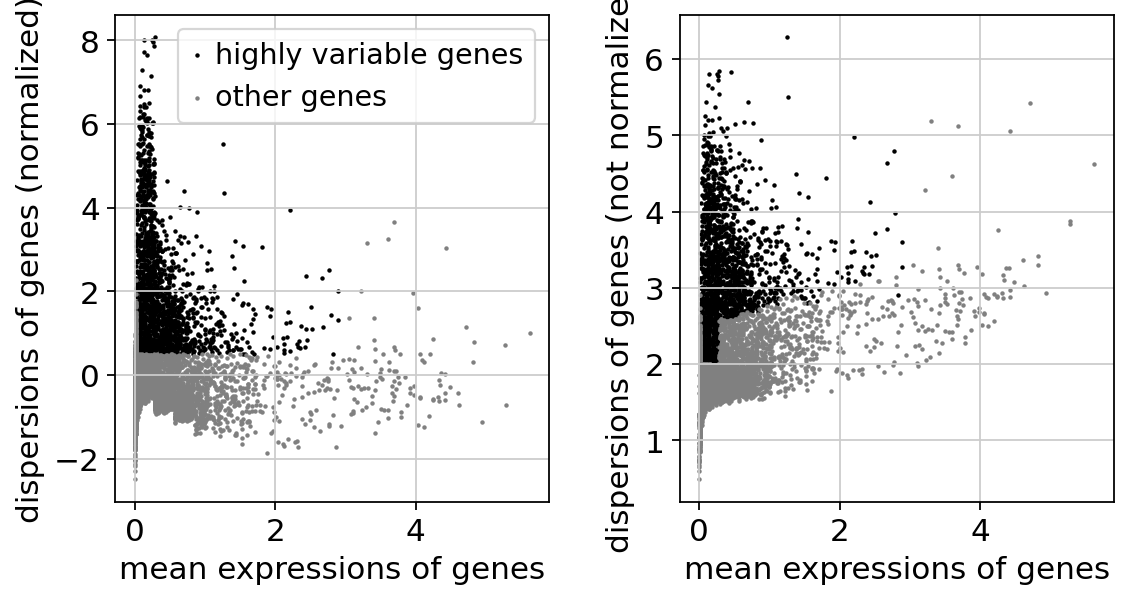

we are regressing out  total_counts True
we are regressing out  pct_counts_mt True
we are regressing out  pct_counts_ribo False
we are regressing out  pct_counts_malat1 False
we are regressing out  pct_counts_hb False
####################################################  Scale the data (each gene to unit variance)


/home/ubuntu/miniconda3/envs/sctl/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:710: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


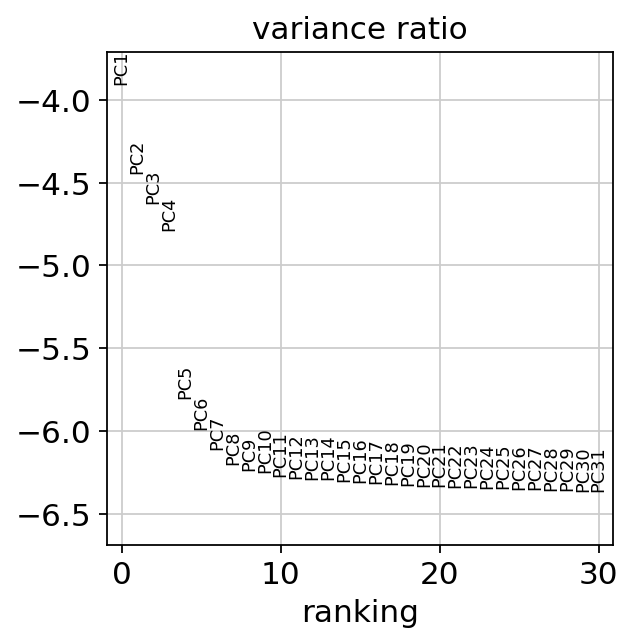

In [40]:


#########################################
## def norm_log()
print(f'####################################################  raw coutn perserved adata.layers["counts"] ')
adata.layers["counts"] = adata.X.copy()  # preserve counts
print(f'####################################################  library-size correct  the data')
################################## library-size correct  the data:
sc.pp.normalize_total(adata, target_sum=normalize_total_target_sum)    
if logarithmize==True:
    print(f'####################################################  Logarithmize  the data')
    print(f'############################# to adata.raw save filtered, normalized and logarithmized gene expression and plot')
    sc.pp.log1p(adata)
else:
     print(f'############################# to adata.raw save filtered and normalized gene expression and plot')
adata.raw = adata

### def HVG_selection_log_norm_sc()

sc.pp.highly_variable_genes(adata, min_mean=HVG_min_mean, max_mean=HVG_max_mean, min_disp=HVG_min_disp)
print(f'############################# the number of highly varriable gens are = ',sum(adata.var.highly_variable))
sc.pl.highly_variable_genes(adata) #### plot HVGs

######################################### filter_HVG
if filter_HVG==True:
    adata = adata[:, adata.var.highly_variable]
else:
    print(f' filter_HVG == False ... all genes will be kept ')
    
    
## regress_out_anotated_QC_genes()

################################# and Regression 
print(f'we are regressing out  total_counts {regress_mt}')
print(f'we are regressing out  pct_counts_mt {regress_mt}')
print(f'we are regressing out  pct_counts_ribo {regress_ribo}')
print(f'we are regressing out  pct_counts_malat1 {regress_malat1}')
print(f'we are regressing out  pct_counts_hb {regress_hb}')

################ Do the regression 
if regress_mt ==True:
    # by total_counts
    sc.pp.regress_out(adata, ['total_counts' ],n_jobs=n_jobs)
if regress_mt ==True:
    # by percent_mt
    sc.pp.regress_out(adata, ['pct_counts_mt' ],n_jobs=n_jobs)
if regress_ribo ==True:
    # by percent_ribo
    sc.pp.regress_out(adata, ['pct_counts_ribo' ],n_jobs=n_jobs)
if regress_malat1 ==True:
    # by percent_hb
    sc.pp.regress_out(adata, ['pct_counts_malat1'],n_jobs=n_jobs)
if regress_hb ==True:
    # by percent_hb
    sc.pp.regress_out(adata, ['pct_counts_hb' ],n_jobs=n_jobs)
    
    
if scale==True:
    print(f'####################################################  Scale the data (each gene to unit variance)')
    sc.pp.scale(adata, max_value=10)  # Scale and Clip values exceeding standard deviation 10.

######################################### PCA
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)

In [41]:
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'total_counts_malat1', 'pct_counts_malat1'
    var: 'gene_ids', 'n_cells', 'n_counts', 'mt', 'ribo', 'hb', 'malat1', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'parameters', 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

sc.pp.neighbors n_pcs= 40
sc.pp.neighbors n_neighbors= 10
sc.tl.leiden resolution= 0.9


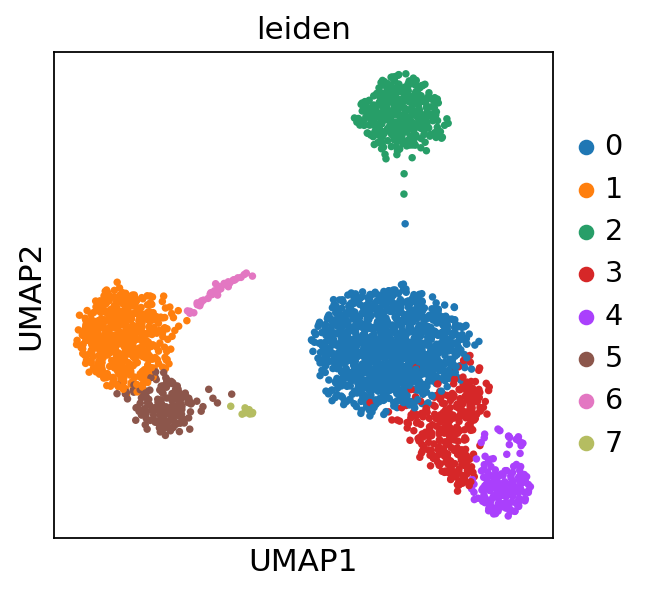

In [42]:


###clustering parameters for clusters

print(f"sc.pp.neighbors n_pcs=",adata.uns["parameters"]['number_of_PC'])
print(f"sc.pp.neighbors n_neighbors=",adata.uns["parameters"]['number_of_neighbors'])
print(f"sc.tl.leiden resolution=",adata.uns["parameters"]['leiden_res'])

sc.pp.neighbors(adata, n_neighbors=number_of_neighbors, n_pcs=number_of_PC)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=leiden_res)
sc.pl.umap(adata, color=['leiden' ] )

In [43]:
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'total_counts_malat1', 'pct_counts_malat1', 'leiden'
    var: 'gene_ids', 'n_cells', 'n_counts', 'mt', 'ribo', 'hb', 'malat1', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'parameters', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [44]:
new_obs_key='leiden_renamed'

cluster_numbers_len=len(set(adata.obs['leiden'].tolist()))
if cluster_numbers_len==len(new_cluster_names):
    adata.obs[new_obs_key]=adata.obs['leiden']
    adata.rename_categories(new_obs_key, new_cluster_names)
    ##################### cluster remnameing #####END

In [45]:
## add a custom color map for the umaps to show zero expression as grey
# Custom colormap where zero values are represented by grey
import matplotlib.colors as mcolors
cmap = mcolors.ListedColormap(['gray'] + list(plt.cm.viridis(np.linspace(0, 1, 256))))

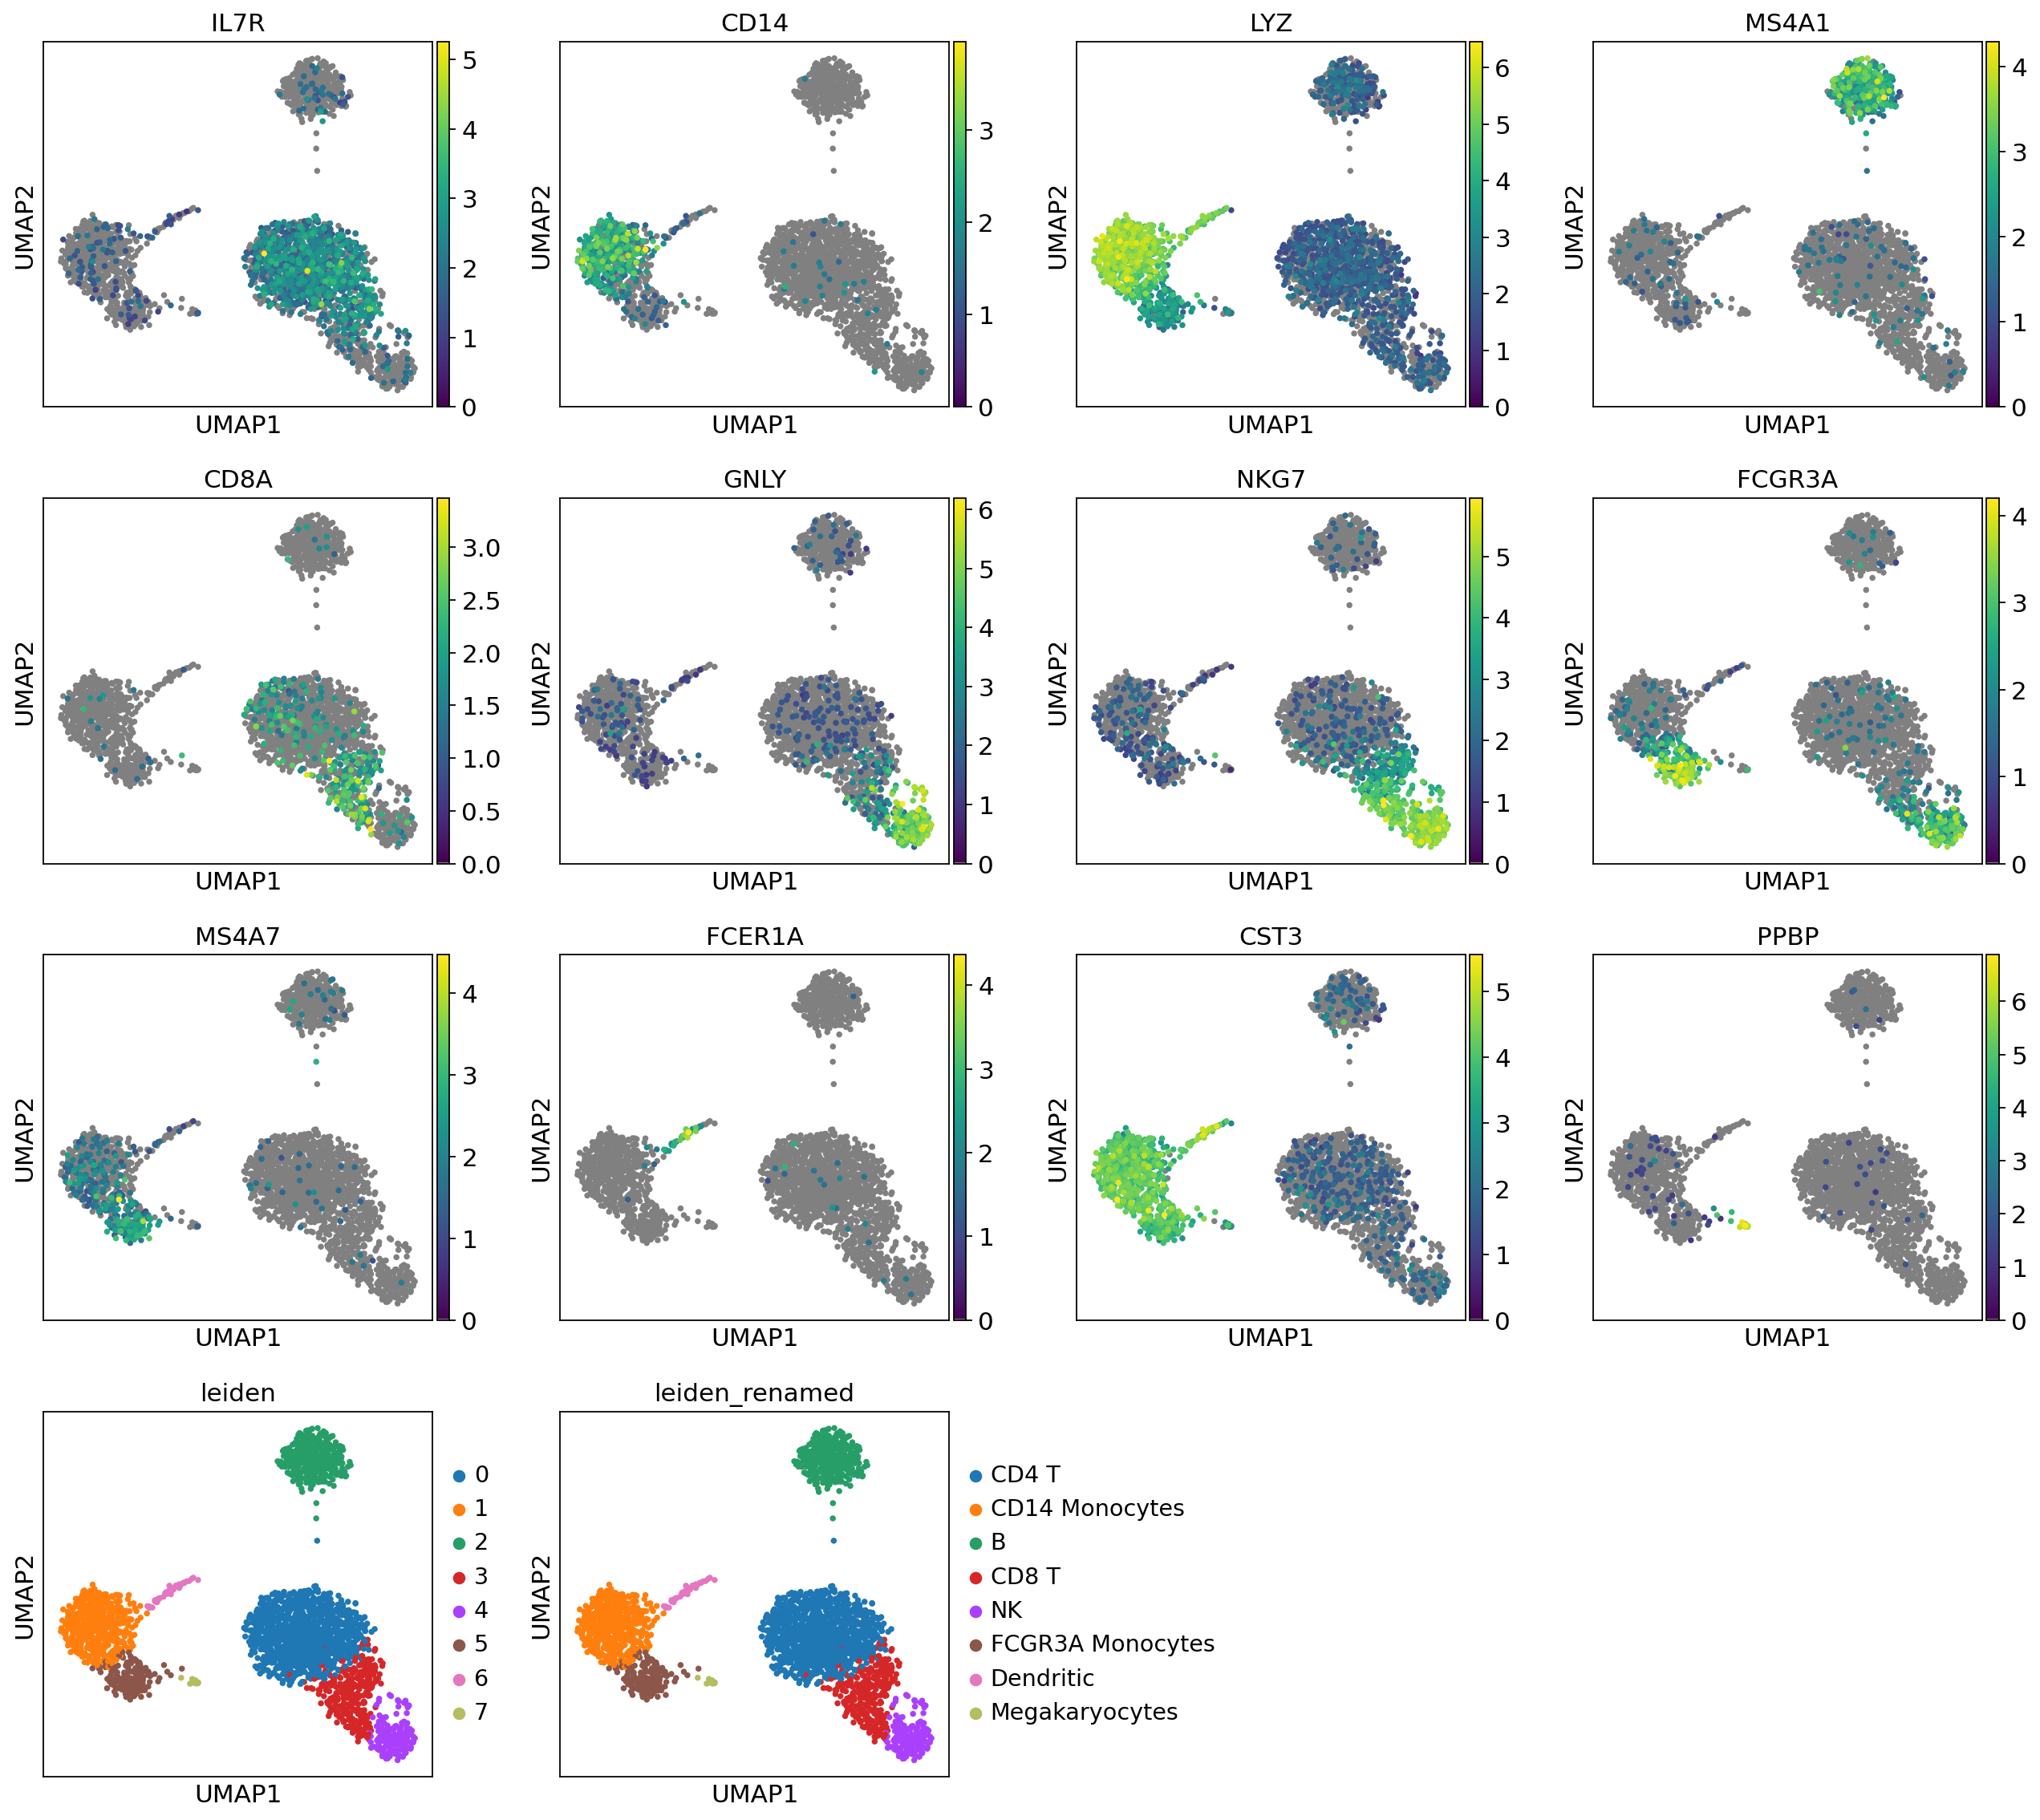

In [46]:
if cluster_numbers_len==len(new_cluster_names):
    umap_marker_gene_list=adata.uns["parameters"]["umap_marker_gene_list"]
    sc.pl.umap(adata, color=umap_marker_gene_list+['leiden','leiden_renamed'], cmap=cmap )

In [47]:
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'total_counts_malat1', 'pct_counts_malat1', 'leiden', 'leiden_renamed'
    var: 'gene_ids', 'n_cells', 'n_counts', 'mt', 'ribo', 'hb', 'malat1', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'parameters', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'leiden_renamed_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

### END  do processing using scanpy fucnitons ( unwraped )